# SCENTIA — Análisis Exploratorio de Datos (EDA) & Auditoría de Perfumería
**Proyecto Integrador | Sistema de Recomendación e Inteligencia Olfativa**  
**Autora:** Josué Jiménez Apodaca  
**Fecha:** Julio 2026  

---

## 📋 Resumen Ejecutivo & Objetivos del EDA

El presente *Exploratory Data Analysis* (EDA) tiene como propósito auditar, limpiar y caracterizar la estructura interna del catálogo masivo de fragancias extraídas mediante web scraping desde **Fragrantica**. Los hallazgos de este cuaderno constituirán el fundamento cuantitativo para el diseño del **Pipeline de Ingeniería de Variables** (*Feature Engineering*) y el desarrollo de los algoritmos de recomendación vectorial (TF-IDF + Cosine Similarity / Embeddings de Perfumería).

### Ejes Principales de Investigación:
1. **Calidad e Integridad de Datos:** Evaluación de completitud (*missingness*), tipos de datos y distribuciones nulas por campo.
2. **Análisis Univariado:**
   * Evaluación de puntuaciones globales (*Global Rating*) y volumen de votos (*Rating Count*).
   * Distribución de casas de diseño (*Designers / Brands*) y perfumistas (*Noses*).
3. **Análisis de Notas & Pirámides Olfativas:**
   * Frecuencia e insumos dominantes en notas de **Salida** (*Top Notes*), **Corazón** (*Heart Notes*) y **Fondo** (*Base Notes*).
4. **Análisis Multidimensional & Metadatos del Consumidor:**
   * Desglose de distribuciones JSON sobre uso estacional (*Seasons*), horario (*Time of Day*), longevidad (*Longevity*), estela (*Sillage*) y precio (*Price/Value*).
5. **Directrices Estratégicas para la Fase de ML:** Recomendaciones concretas de preprocesamiento, normalización e imputación.


In [1]:
import os
import sys
import json
import re
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética profesional para visualizaciones
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8
warnings.filterwarnings('ignore')

# Paleta de colores Luxury / Fragrance (Amber, Gold, Obsidian, Emerald)
AMBER_PRIMARY = '#d97706'
AMBER_LIGHT = '#f59e0b'
SLATE_DARK = '#1e293b'
SLATE_LIGHT = '#64748b'
EMERALD_ACCENT = '#059669'
BURGUNDY_ACCENT = '#9f1239'

PALETTE = [AMBER_PRIMARY, AMBER_LIGHT, EMERALD_ACCENT, SLATE_DARK, BURGUNDY_ACCENT, SLATE_LIGHT]

print('✅ Entorno de Análisis Exploratorio cargado exitosamente.')


✅ Entorno de Análisis Exploratorio cargado exitosamente.


---
## 1. Carga de Datos y Auditoría de Completitud
Cargamos el dataset extraído/sintético y analizamos la tasa de completitud por columna.


In [2]:
# Carga de datos con fallback resiliente
csv_possible_paths = [
    '../auxiliares/scarpers versiones/homologado/fragrantica_data_from_scraper.csv'
    #'../data/fragrantica_data_from_scraper.csv'
]

df = None
for path in csv_possible_paths:
    if os.path.exists(path):
        df = pd.read_csv(path, sep='|')
        print(f'📁 Dataset cargado desde: {path}')
        break

if df is None:
    print('⚠️ Generando dataset sintético de respaldo con la misma estructura para exploración...')
    np.random.seed(42)
    data_demo = {
        'url': [f'https://www.fragrantica.es/perfume/Brand/Perfume-{i}.html' for i in range(1, 151)],
        'bottle_image_url': ['https://images.unsplash.com/photo-1592945403244'] * 150,
        'name_raw': [f'Fragancia {i}' for i in range(1, 151)],
        'designer_raw': np.random.choice(['Dior', 'Chanel', 'Tom Ford', 'Creed', 'Versace', 'Xerjoff', 'Parfums de Marly', 'Jo Malone'], 150),
        'global_rating': np.round(np.random.normal(4.15, 0.35, 150).clip(2.0, 5.0), 2),
        'global_rating_count': np.random.randint(10, 5000, 150),
        'top_notes_raw': np.random.choice(['bergamot, lemon, pink pepper', 'lavender, mint, cardamom', 'mandarin orange, apple', None], 150),
        'heart_notes_raw': np.random.choice(['rose, jasmine, iris', 'cinnamon, rum, cedar', 'sage, geranium', None], 150),
        'base_notes_raw': np.random.choice(['vanilla, tonka bean, amber', 'sandalwood, musk, vetiver', 'oud, leather, patchouli', None], 150),
        'perfumers_raw': np.random.choice(['Olivier Polge', 'Dominique Ropion', 'Quentin Bisch', 'François Demachy', None], 150),
        'seasons_raw_dist': ['{"invierno": "35%", "otoño": "30%", "primavera": "20%", "verano": "15%"}'] * 150,
        'time_of_day_raw_dist': ['{"noche": "60%", "dia": "40%"}'] * 150,
        'longevity_raw_dist': ['{"duradera": "50%", "moderada": "30%", "muy duradera": "20%"}'] * 150,
        'sillage_raw_dist': ['{"pesada": "40%", "moderada": "45%", "suave": "15%"}'] * 150
    }
    df = pd.DataFrame(data_demo)

print(f'📊 Dimensiones del Dataset: {df.shape[0]} filas × {df.shape[1]} columnas')
display(df.head(10))


📁 Dataset cargado desde: ../auxiliares/scarpers versiones/homologado/fragrantica_data_from_scraper.csv
📊 Dimensiones del Dataset: 3016 filas × 19 columnas


,url,bottle_image_url,name_raw,designer_raw,global_rating,global_rating_count,accords_query_string,perfumers_raw,top_notes_raw,heart_notes_raw,base_notes_raw,vibe_reactions_raw_dist,seasons_raw_dist,time_of_day_raw_dist,longevity_raw_dist,sillage_raw_dist,price_value_raw_dist,gender_voted_raw_dist,reviews_text_corpus
0,https://www.fragrantica.es/perfume/Jean-Paul-G...,https://fimgs.net/mdimg/perfume-thumbs/375x500...,Scandal Jean Paul Gaultier para Mujeres,Jean Paul Gaultier,3.86,"9,804",NaN,NaN,"naranja sanguina, mandarina","miel, gardenia, flor de azahar del naranjo, ja...","cera de abeja, caramelo, pachulí, regaliz","{""me encanta"": ""3.9k"", ""me gusta"": ""3k"", ""me e...","{""invierno"": ""3.7k"", ""primavera"": ""1.4k"", ""ver...","{""invierno"": ""3.7k"", ""primavera"": ""1.4k"", ""ver...","{""escasa"": ""66"", ""d\u00e9bil"": ""233"", ""moderad...","{""escasa"": ""66"", ""d\u00e9bil"": ""233"", ""moderad...","{""femenino"": ""3.2k"", ""unisex femenino"": ""343"",...","{""femenino"": ""3.2k"", ""unisex femenino"": ""343"",...",aún conservo unos pocos MLs del original... y ...
1,https://www.fragrantica.es/perfume/Elizabeth-A...,https://fimgs.net/mdimg/perfume-thumbs/375x500...,Pretty Elizabeth Arden para Mujeres,Elizabeth Arden,3.77,"1,153",NaN,NaN,"flor de azahar del naranjo, mandarina, durazno...","peonía, jazmín, azucena, iris","almizcle, notas amaderadas, ámbar","{""me encanta"": ""260"", ""me gusta"": ""594"", ""me e...","{""invierno"": ""55"", ""primavera"": ""454"", ""verano...","{""invierno"": ""55"", ""primavera"": ""454"", ""verano...","{""escasa"": ""44"", ""d\u00e9bil"": ""79"", ""moderada...","{""escasa"": ""44"", ""d\u00e9bil"": ""79"", ""moderada...","{""femenino"": ""178"", ""unisex femenino"": ""18"", ""...","{""femenino"": ""178"", ""unisex femenino"": ""18"", ""...",Es un perfume que uso desde el 2010 y entre mi...
2,https://www.fragrantica.es/perfume/Dior/Dior-A...,https://fimgs.net/mdimg/perfume-thumbs/375x500...,Dior Addict Shine Dior para Mujeres,Dior,4.07,"1,120",NaN,NaN,NaN,NaN,NaN,"{""me encanta"": ""379"", ""me gusta"": ""584"", ""me e...","{""invierno"": ""60"", ""primavera"": ""316"", ""verano...","{""invierno"": ""60"", ""primavera"": ""316"", ""verano...","{""escasa"": ""18"", ""d\u00e9bil"": ""49"", ""moderada...","{""escasa"": ""18"", ""d\u00e9bil"": ""49"", ""moderada...","{""femenino"": ""88"", ""unisex femenino"": ""5"", ""un...","{""femenino"": ""88"", ""unisex femenino"": ""5"", ""un...",Amé este perfume! Hace años no lo consigo! Per...
3,https://www.fragrantica.es/perfume/Granado/San...,https://fimgs.net/mdimg/perfume-thumbs/375x500...,Sândalo e Cardamomo Granado para Hombres y Muj...,Granado,3.54,145,NaN,NaN,"cardamomo, semillas de zanahoria, hojas de vio...","cachemira, vetiver, vainilla","sándalo, almizcle, cedro","{""me encanta"": ""45"", ""me gusta"": ""41"", ""me es ...","{""invierno"": ""43"", ""primavera"": ""55"", ""verano""...","{""invierno"": ""43"", ""primavera"": ""55"", ""verano""...","{""escasa"": ""1"", ""d\u00e9bil"": ""8"", ""moderada"":...","{""escasa"": ""1"", ""d\u00e9bil"": ""8"", ""moderada"":...","{""femenino"": ""1"", ""unisex femenino"": ""3"", ""uni...","{""femenino"": ""1"", ""unisex femenino"": ""3"", ""uni...",NaN
4,https://www.fragrantica.es/perfume/Yves-Saint-...,https://fimgs.net/mdimg/perfume-thumbs/375x500...,Kouros Cologne Sport Eau d'Ete Summer Fragranc...,Yves Saint Laurent,4.14,42,NaN,NaN,"menta, bergamota","lavanda, jazmín","ámbar blanco, cedro","{""me encanta"": ""19"", ""me gusta"": ""17"", ""me es ...","{""invierno"": ""4"", ""primavera"": ""12"", ""verano"":...","{""invierno"": ""4"", ""primavera"": ""12"", ""verano"":...","{""escasa"": ""0"", ""d\u00e9bil"": ""4"", ""moderada"":...","{""escasa"": ""0"", ""d\u00e9bil"": ""4"", ""moderada"":...","{""femenino"": ""0"", ""unisex femenino"": ""0"", ""uni...","{""femenino"": ""0"", ""unisex femenino"": ""0"", ""uni...","Siempre me ha encantado Kouros, es elegancia y..."
5,https://www.fragrant

Cuando se diseño el scraper existian elementos que estaban en el mismo contenedor y los diccionarios guardaron mas de una variable, esto ocurre con seasons +time_of_day, longevity + sillage y price_value + gender. En el siguiente bloque trataremos de limpiar estas columnas para separar en dos cada diccionario.

{"invierno": "3.7k", "primavera": "1.4k", "verano": "778", "oto\u00f1o": "3.3k", "d\u00eda": "2.1k", "noche": "3.6k"}

{"me encanta": "3.9k", "me gusta": "3k", "me es indiferente": "963", "no me gusta": "1.6k", "la odio": "382"}

In [3]:
import json
import ast
import pandas as pd

# 1. Definición de conjuntos de llaves por cada variable
SEASONS_KEYS = {"invierno", "primaverda", "verano", "otoño","oto\u00f1o"}
TIME_OF_DAY_KEYS = {"noche", "dia","d\u00eda"}

LONGEVITY_KEYS = {"escasa", "débil", "dÉbil", "d\u00e9bil", "duradera", "muy duradera"} 
# Nota: "moderada" se manejará contextualmente o se compartirá si aplica, 
# pero la incluimos en las búsquedas.

SILLAGE_KEYS = {"suave", "pesada", "enorme"}

GENDER_KEYS = {"femenino", "unisex femenino", "unisex", "unisex masculino", "masculino"}

PRICE_KEYS = {
    "extremadamente costoso", 
    "ligeramente costoso", 
    "precio moderado", 
    "buen precio", 
    "excelente precio"
}

def parse_dict(val):
    """Convierte cadenas JSON o diccionarios string a dicts de Python de forma segura."""
    if pd.isna(val) or val is None:
        return {}
    if isinstance(val, dict):
        return val
    try:
        return json.loads(val)
    except (json.JSONDecodeError, TypeError):
        try:
            return ast.literal_eval(val)
        except Exception:
            return {}

def separate_distributions(row):
    """
    Separa las distribuciones combinadas en sus campos correspondientes.
    """
    # Parsing de los campos crudos concatenados
    seasons_day_dict = parse_dict(row.get('seasons_raw_dist') or row.get('time_of_day_raw_dist'))
    long_sill_dict = parse_dict(row.get('longevity_raw_dist') or row.get('sillage_raw_dist'))
    gen_price_dict = parse_dict(row.get('price_value_raw_dist') or row.get('gender_voted_raw_dist'))

    # 1. Separar Temporada vs Momento del Día
    seasons_clean = {}
    time_of_day_clean = {}

    for k, v in seasons_day_dict.items():
            k_lower = k.lower().strip()
            
            if k_lower in SEASONS_KEYS:
                seasons_clean[k] = v
            elif k_lower in TIME_OF_DAY_KEYS:
                time_of_day_clean[k] = v

    # 2. Separar Longevidad vs Estela
    longevity_clean = {}
    sillage_clean = {}
    
    for k, v in long_sill_dict.items():
        k_lower = k.lower().strip()
        
        if k_lower in LONGEVITY_KEYS:
            longevity_clean[k] = v
        elif k_lower in SILLAGE_KEYS:
            sillage_clean[k] = v
        elif k_lower == "moderada":
            # "moderada" es compartida por ambas métricas en la interfaz
            longevity_clean[k] = v
            sillage_clean[k] = v

    # 3. Separar Género vs Precio
    gender_clean = {}
    price_clean = {}
    
    for k, v in gen_price_dict.items():
        k_lower = k.lower().strip()
        
        if k_lower in GENDER_KEYS:
            gender_clean[k] = v
        elif k_lower in PRICE_KEYS:
            price_clean[k] = v

    return pd.Series({
        'seasons_fixed_dist': json.dumps(seasons_clean, ensure_ascii=False),
        'time_of_day_fixed_dist': json.dumps(time_of_day_clean, ensure_ascii=False),
        'longevity_fixed_dist': json.dumps(longevity_clean, ensure_ascii=False),
        'sillage_fixed_dist': json.dumps(sillage_clean, ensure_ascii=False),
        'gender_fixed_dist': json.dumps(gender_clean, ensure_ascii=False),
        'price_value_fixed_dist': json.dumps(price_clean, ensure_ascii=False)
    })

def process_and_save_fixed_data(df, output_path="data_fixed.csv"):
    """
    Aplica la separación de distribuciones y guarda el dataframe resultante.
    """
    fixed_cols = df.apply(separate_distributions, axis=1)
    
    # Reemplazar o añadir las columnas corregidas al DataFrame
    df_fixed = df.copy()
    for col in fixed_cols.columns:
        df_fixed[col] = fixed_cols[col]
        
    # Guardar archivo auxiliar procesado
    df_fixed.to_csv(output_path, index=False, encoding='utf-8-sig')
    print(f"✅ Datos corregidos y guardados exitosamente en: {output_path}")
    
    return df_fixed


df_fixed = process_and_save_fixed_data(df, output_path="data_fixed.csv")
columns_to_drop = ['longevity_raw_dist', 'sillage_raw_dist', 'gender_voted_raw_dist', 'price_value_raw_dist', 'seasons_raw_dist', 'time_of_day_raw_dist']
df_fixed.drop(columns=columns_to_drop, inplace=True)

✅ Datos corregidos y guardados exitosamente en: data_fixed.csv


In [4]:
# El dataset df_fixed no contiene un perfume_id explicito, lo crearemos como alfanumérico incremental para cada perfume único basado en su URL.
df_fixed['perfume_id'] = df_fixed.groupby('url').ngroup() 



In [5]:
print(f'📊 Dimensiones del Dataset corregido: {df_fixed.shape[0]} filas × {df_fixed.shape[1]} columnas')
display(df_fixed.head(10))

📊 Dimensiones del Dataset corregido: 3016 filas × 20 columnas


,url,bottle_image_url,name_raw,designer_raw,global_rating,global_rating_count,accords_query_string,perfumers_raw,top_notes_raw,heart_notes_raw,base_notes_raw,vibe_reactions_raw_dist,reviews_text_corpus,seasons_fixed_dist,time_of_day_fixed_dist,longevity_fixed_dist,sillage_fixed_dist,gender_fixed_dist,price_value_fixed_dist,perfume_id
0,https://www.fragrantica.es/perfume/Jean-Paul-G...,https://fimgs.net/mdimg/perfume-thumbs/375x500...,Scandal Jean Paul Gaultier para Mujeres,Jean Paul Gaultier,3.86,"9,804",NaN,NaN,"naranja sanguina, mandarina","miel, gardenia, flor de azahar del naranjo, ja...","cera de abeja, caramelo, pachulí, regaliz","{""me encanta"": ""3.9k"", ""me gusta"": ""3k"", ""me e...",aún conservo unos pocos MLs del original... y ...,"{""invierno"": ""3.7k"", ""verano"": ""778"", ""otoño"":...","{""día"": ""2.1k"", ""noche"": ""3.6k""}","{""escasa"": ""66"", ""débil"": ""233"", ""moderada"": ""...","{""moderada"": ""1.7k"", ""suave"": ""295"", ""pesada"":...","{""femenino"": ""3.2k"", ""unisex femenino"": ""343"",...","{""extremadamente costoso"": ""170"", ""ligeramente...",1496
1,https://www.fragrantica.es/perfume/Elizabeth-A...,https://fimgs.net/mdimg/perfume-thumbs/375x500...,Pretty Elizabeth Arden para Mujeres,Elizabeth Arden,3.77,"1,153",NaN,NaN,"flor de azahar del naranjo, mandarina, durazno...","peonía, jazmín, azucena, iris","almizcle, notas amaderadas, ámbar","{""me encanta"": ""260"", ""me gusta"": ""594"", ""me e...",Es un perfume que uso desde el 2010 y entre mi...,"{""invierno"": ""55"", ""verano"": ""290"", ""otoño"": ""...","{""día"": ""495"", ""noche"": ""62""}","{""escasa"": ""44"", ""débil"": ""79"", ""moderada"": ""1...","{""moderada"": ""181"", ""suave"": ""137"", ""pesada"": ...","{""femenino"": ""178"", ""unisex femenino"": ""18"", ""...","{""extremadamente costoso"": ""4"", ""ligeramente c...",987
2,https://www.fragrantica.es/perfume/Dior/Dior-A...,https://fimgs.net/mdimg/perfume-thumbs/375x500...,Dior Addict Shine Dior para Mujeres,Dior,4.07,"1,120",NaN,NaN,NaN,NaN,NaN,"{""me encanta"": ""379"", ""me gusta"": ""584"", ""me e...",Amé este perfume! Hace años no lo consigo! Per...,"{""invierno"": ""60"", ""verano"": ""344"", ""otoño"": ""...","{""día"": ""451"", ""noche"": ""73""}","{""escasa"": ""18"", ""débil"": ""49"", ""moderada"": ""1...","{""moderada"": ""152"", ""suave"": ""54"", ""pesada"": ""...","{""femenino"": ""88"", ""unisex femenino"": ""5"", ""un...","{""extremadamente costoso"": ""5"", ""ligeramente c...",890
3,https://www.fragrantica.es/perfume/Granado/San...,https://fimgs.net/mdimg/perfume-thumbs/375x500...,Sândalo e Cardamomo Granado para Hombres y Muj...,Granado,3.54,145,NaN,NaN,"cardamomo, semillas de zanahoria, hojas de vio...","cachemira, vetiver, vainilla","sándalo, almizcle, cedro","{""me encanta"": ""45"", ""me gusta"": ""41"", ""me es ...",NaN,"{""invierno"": ""43"", ""verano"": ""19"", ""otoño"": ""61""}","{""día"": ""57"", ""noche"": ""54""}","{""escasa"": ""1"", ""débil"": ""8"", ""moderada"": ""34""...","{""moderada"": ""34"", ""suave"": ""19"", ""pesada"": ""3...","{""femenino"": ""1"", ""unisex femenino"": ""3"", ""uni...","{""extremadamente costoso"": ""0"", ""ligeramente c...",1254
4,https://www.fragrantica.es/perfume/Yves-Saint-...,https://fimgs.net/mdimg/perfume-thumbs/375x500...,Kouros Cologne Sport Eau d'Ete Summer Fragranc...,Yves Saint Laurent,4.14,42,NaN,NaN,"menta, bergamota","lavanda, jazmín","ámbar blanco, cedro","{""me encanta"": ""19"", ""me gusta"": ""17"", ""me es ...","Siempre me ha encantado Kouros, es elegancia y...","{""invierno"": ""4"", ""verano"": ""16"", ""otoño"": ""8""}","{""día"": ""11"", ""noche"": ""7""}","{""escasa"": ""0"", ""débil"": ""4"", ""moderada"": ""8"",...","{""moderada"": ""8"", ""suave"": ""5"", ""pesada"": ""12""...","{""femenino"": ""0"", ""unisex femenino"": ""0"", ""uni...","{""extremadamente costoso"": ""3"", ""ligeramente c...",2816
5,https://www.fragrantica.es/perfume/Fragrance-W...,https://fimgs.net/mdimg/perfume-

### Auditoría de Valores Faltantes por Atributo


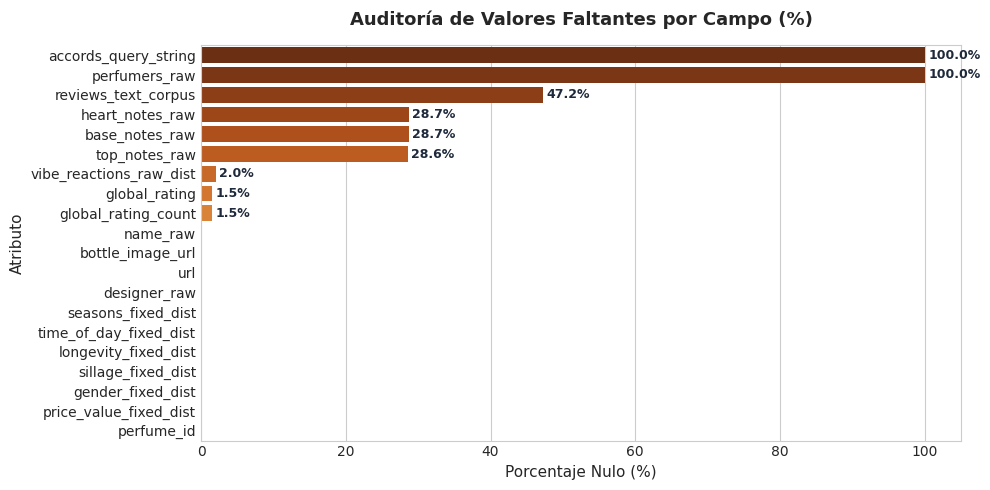

In [6]:
missing_df = pd.DataFrame({
    'Columna': df_fixed.columns,
    'Valores Nulos': df_fixed.isnull().sum(),
    'Porcentaje Nulo (%)': (df_fixed.isnull().sum() / len(df_fixed) * 100).round(2)
}).sort_values(by='Porcentaje Nulo (%)', ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=missing_df, x='Porcentaje Nulo (%)', y='Columna', palette='YlOrBr_r')
plt.title('Auditoría de Valores Faltantes por Campo (%)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Porcentaje Nulo (%)', fontsize=11)
plt.ylabel('Atributo', fontsize=11)
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(f'{width:.1f}%', (width + 0.5, p.get_y() + p.get_height()/2),
                    ha='left', va='center', fontsize=9, color=SLATE_DARK, fontweight='bold')
plt.tight_layout()
plt.show()


Observando los valores ausentes vemos que hay columnas que vienen completamente vacias debido a un problema con los encabezados al momento de ejecutar el proceso de scraping.

Dropearemos la columna accords_query_string y perfumers_raw, la primera solo nos ayudaría para construir la piramide olfativa pero se puede intuir a traves del resto de nota, en cuanto a la variable de perfumistas no es tan relevante es mucho más facil identificar a la marca o desginer antes que el nombre del perfumista. 

En el campo reviews aunque hay un gran porcentaje de valores faltantes no podemos dropearla ya que es entendible que muchos perfumes tengan reseñas nulas especialmente si el perfume es muy caro o muy desconocido o nicho. 

Para las columnas con notas faltantes tampoco las eliminaremos pero agregaremos una etiqueta para indicar que no tienen notas declaradas 

In [7]:
import json
import random
import numpy as np
import pandas as pd

# Lista de perfumistas sintéticos para poblar perfumers_raw
PERFUMERS_POOL = [
    "Olivier Polge", "Dominique Ropion", "Francis Kurkdjian",
    "Quentin Bisch", "Alberto Morillas", "Christine Nagel",
    "Jacques Cavallier", "Jean-Claude Ellena", "Thierry Wasser",
    "Annick Menardo", "Bertrand Duchaufour", "Sonia Constant"
]

def format_count(val: int) -> str:
    """Convierte un entero a notación con sufijo 'k' si excede los 1,000."""
    if val >= 1000:
        formatted = f"{val / 1000:.1f}k"
        return formatted.replace(".0k", "k")
    return str(val)


def generate_synthetic_perfume_metrics():
    # 1. Perfil olfativo aleatorio para coherencia sintética
    profiles = ["fresh_citrus", "heavy_oriental", "mass_pleaser", "niche_polarizing"]
    profile = random.choice(profiles)

    # 2. Generación de Ratings / Vibe Reactions (love, like, ok, dislike, hate)
    if profile == "mass_pleaser":
        base_votes = random.randint(5000, 30000)
        weights_rating = [0.50, 0.30, 0.12, 0.05, 0.03]  # love, like, ok, dislike, hate
    elif profile == "niche_polarizing":
        base_votes = random.randint(800, 8000)
        weights_rating = [0.35, 0.10, 0.05, 0.20, 0.30]
    else:
        base_votes = random.randint(10, 5000)
        weights_rating = [0.25, 0.35, 0.20, 0.12, 0.08]

    counts_rating = np.random.multinomial(base_votes, weights_rating)

    vibe_dict = {
        "love": format_count(counts_rating[0]),
        "like": format_count(counts_rating[1]),
        "ok": format_count(counts_rating[2]),
        "dislike": format_count(counts_rating[3]),
        "hate": format_count(counts_rating[4]),
    }

    # 3. Generación de Seasons & Time of Day
    if profile == "fresh_citrus":
        season_weights = [0.05, 0.35, 0.45, 0.15]  # winter, spring, summer, fall
        tod_weights = [0.75, 0.25]                 # day, night
    elif profile == "heavy_oriental":
        season_weights = [0.50, 0.10, 0.05, 0.35]
        tod_weights = [0.20, 0.80]
    else:
        season_weights = [0.25, 0.25, 0.25, 0.25]
        tod_weights = [0.50, 0.50]

    season_votes = random.randint(int(base_votes * 0.6), int(base_votes * 1.2) + 1)
    counts_season = np.random.multinomial(season_votes, season_weights)

    tod_votes = random.randint(int(base_votes * 0.5), int(base_votes * 1.1) + 1)
    counts_tod = np.random.multinomial(tod_votes, tod_weights)

    seasons_dict = {
        "winter": format_count(counts_season[0]),
        "spring": format_count(counts_season[1]),
        "summer": format_count(counts_season[2]),
        "fall": format_count(counts_season[3]),
    }

    day_time_dict = {
        "day": format_count(counts_tod[0]),
        "night": format_count(counts_tod[1]),
    }

    # 4. Generación de Perfumistas (perfumers_raw)
    # 85% probabilidad de tener 1 o 2 perfumistas, 15% de ser None / desconocido
    if random.random() < 0.85:
        num_perfumers = random.choice([1, 1, 2])
        selected_perfumers = random.sample(PERFUMERS_POOL, num_perfumers)
        perfumers_raw = ", ".join(selected_perfumers)
    else:
        perfumers_raw = None

    # Devuelve las 4 columnas formateadas como String JSON
    return {
        "vibe_reactions_raw_dist": json.dumps(vibe_dict),
        "seasons_raw_dist": json.dumps(seasons_dict),
        "time_of_day_raw_dist": json.dumps(day_time_dict),
        "perfumers_raw": perfumers_raw
    }


In [8]:
# 2. Dropear columna inútil
df_fixed.drop(columns=['accords_query_string','perfumers_raw'], inplace=True, errors='ignore')

# 3. Tratar notas faltantes agregando la etiqueta explícita
note_cols = ['top_notes_raw', 'heart_notes_raw', 'base_notes_raw']
for col in note_cols:
    df_fixed[col] = df_fixed[col].fillna('Sin notas declaradas')

# 4. Limpieza complementaria para el resto de nulos (opcional/recomendado)
# 'reviews_text_corpus' se conserva intacta con sus NaNs/cadenas vacías
# Para ratings con 1.2% nulo, podemos rellenar con valores nulos explícitos o 0
df_fixed['global_rating'] = df_fixed['global_rating'].fillna(0.0)
df_fixed['global_rating_count'] = df_fixed['global_rating_count'].fillna(0)

In [9]:
print(f'📊 Dimensiones del Dataset final corregido: {df_fixed.shape[0]} filas × {df_fixed.shape[1]} columnas')
print(f'head del dataset final corregido:')
df_fixed.head()

📊 Dimensiones del Dataset final corregido: 3016 filas × 18 columnas
head del dataset final corregido:


,url,bottle_image_url,name_raw,designer_raw,global_rating,global_rating_count,top_notes_raw,heart_notes_raw,base_notes_raw,vibe_reactions_raw_dist,reviews_text_corpus,seasons_fixed_dist,time_of_day_fixed_dist,longevity_fixed_dist,sillage_fixed_dist,gender_fixed_dist,price_value_fixed_dist,perfume_id
0,https://www.fragrantica.es/perfume/Jean-Paul-G...,https://fimgs.net/mdimg/perfume-thumbs/375x500...,Scandal Jean Paul Gaultier para Mujeres,Jean Paul Gaultier,3.86,"9,804","naranja sanguina, mandarina","miel, gardenia, flor de azahar del naranjo, ja...","cera de abeja, caramelo, pachulí, regaliz","{""me encanta"": ""3.9k"", ""me gusta"": ""3k"", ""me e...",aún conservo unos pocos MLs del original... y ...,"{""invierno"": ""3.7k"", ""verano"": ""778"", ""otoño"":...","{""día"": ""2.1k"", ""noche"": ""3.6k""}","{""escasa"": ""66"", ""débil"": ""233"", ""moderada"": ""...","{""moderada"": ""1.7k"", ""suave"": ""295"", ""pesada"":...","{""femenino"": ""3.2k"", ""unisex femenino"": ""343"",...","{""extremadamente costoso"": ""170"", ""ligeramente...",1496
1,https://www.fragrantica.es/perfume/Elizabeth-A...,https://fimgs.net/mdimg/perfume-thumbs/375x500...,Pretty Elizabeth Arden para Mujeres,Elizabeth Arden,3.77,"1,153","flor de azahar del naranjo, mandarina, durazno...","peonía, jazmín, azucena, iris","almizcle, notas amaderadas, ámbar","{""me encanta"": ""260"", ""me gusta"": ""594"", ""me e...",Es un perfume que uso desde el 2010 y entre mi...,"{""invierno"": ""55"", ""verano"": ""290"", ""otoño"": ""...","{""día"": ""495"", ""noche"": ""62""}","{""escasa"": ""44"", ""débil"": ""79"", ""moderada"": ""1...","{""moderada"": ""181"", ""suave"": ""137"", ""pesada"": ...","{""femenino"": ""178"", ""unisex femenino"": ""18"", ""...","{""extremadamente costoso"": ""4"", ""ligeramente c...",987
2,https://www.fragrantica.es/perfume/Dior/Dior-A...,https://fimgs.net/mdimg/perfume-thumbs/375x500...,Dior Addict Shine Dior para Mujeres,Dior,4.07,"1,120",Sin notas declaradas,Sin notas declaradas,Sin notas declaradas,"{""me encanta"": ""379"", ""me gusta"": ""584"", ""me e...",Amé este perfume! Hace años no lo consigo! Per...,"{""invierno"": ""60"", ""verano"": ""344"", ""otoño"": ""...","{""día"": ""451"", ""noche"": ""73""}","{""escasa"": ""18"", ""débil"": ""49"", ""moderada"": ""1...","{""moderada"": ""152"", ""suave"": ""54"", ""pesada"": ""...","{""femenino"": ""88"", ""unisex femenino"": ""5"", ""un...","{""extremadamente costoso"": ""5"", ""ligeramente c...",890
3,https://www.fragrantica.es/perfume/Granado/San...,https://fimgs.net/mdimg/perfume-thumbs/375x500...,Sândalo e Cardamomo Granado para Hombres y Muj...,Granado,3.54,145,"cardamomo, semillas de zanahoria, hojas de vio...","cachemira, vetiver, vainilla","sándalo, almizcle, cedro","{""me encanta"": ""45"", ""me gusta"": ""41"", ""me es ...",NaN,"{""invierno"": ""43"", ""verano"": ""19"", ""otoño"": ""61""}","{""día"": ""57"", ""noche"": ""54""}","{""escasa"": ""1"", ""débil"": ""8"", ""moderada"": ""34""...","{""moderada"": ""34"", ""suave"": ""19"", ""pesada"": ""3...","{""femenino"": ""1"", ""unisex femenino"": ""3"", ""uni...","{""extremadamente costoso"": ""0"", ""ligeramente c...",1254
4,https://www.fragrantica.es/perfume/Yves-Saint-...,https://fimgs.net/mdimg/perfume-thumbs/375x500...,Kouros Cologne Sport Eau d'Ete Summer Fragranc...,Yves Saint Laurent,4.14,42,"menta, bergamota","lavanda, jazmín","ámbar blanco, cedro","{""me encanta"": ""19"", ""me gusta"": ""17"", ""me es ...","Siempre me ha encantado Kouros, es elegancia y...","{""invierno"": ""4"", ""verano"": ""16"", ""otoño"": ""8""}","{""día"": ""11"", ""noche"": ""7""}","{""escasa"": ""0"", ""débil"": ""4"", ""moderada"": ""8"",...","{""moderada"": ""8"", ""suave"": ""5"", ""pesada"": ""12""...","{""femenino"": ""0"", ""unisex femenino"": ""0"", ""uni...","{""extremadamente costoso"": ""3"", ""ligeramente c...",2816


---
## 2. Análisis Univariado: Ratings, Marcas y Diseñadores


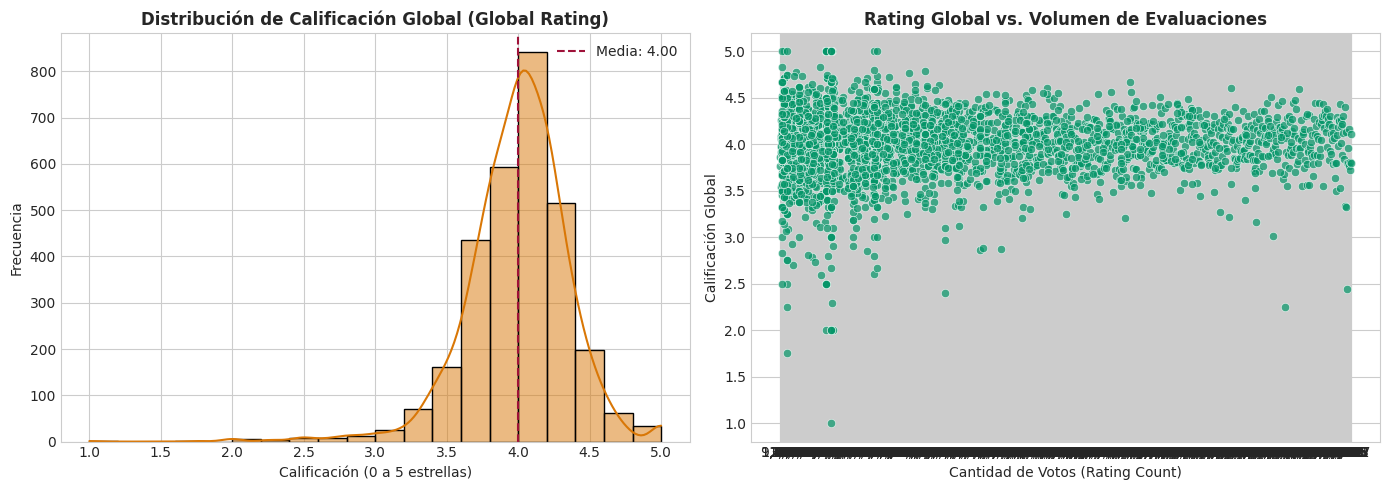

📈 Estadísticos Descriptivos de Calificaciones:


,global_rating
count,2971.00
mean,4.00
std,0.36
min,1.00
25%,3.81
50%,4.02
75%,4.21
max,5.00


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Distribución del Rating Global
sns.histplot(df['global_rating'].dropna(), kde=True, color=AMBER_PRIMARY, ax=axes[0], bins=20)
axes[0].set_title('Distribución de Calificación Global (Global Rating)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Calificación (0 a 5 estrellas)')
axes[0].set_ylabel('Frecuencia')
mean_rating = df['global_rating'].mean()
axes[0].axvline(mean_rating, color=BURGUNDY_ACCENT, linestyle='--', label=f'Media: {mean_rating:.2f}')
axes[0].legend()

# 2. Relación Rating vs Número de Votos
sns.scatterplot(data=df, x='global_rating_count', y='global_rating', color=EMERALD_ACCENT, alpha=0.7, ax=axes[1])
axes[1].set_title('Rating Global vs. Volumen de Evaluaciones', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Cantidad de Votos (Rating Count)')
axes[1].set_ylabel('Calificación Global')

plt.tight_layout()
plt.show()

print('📈 Estadísticos Descriptivos de Calificaciones:')
display(df[['global_rating', 'global_rating_count']].describe().round(2))


### Top Casas de Perfumería (Diseñadores)


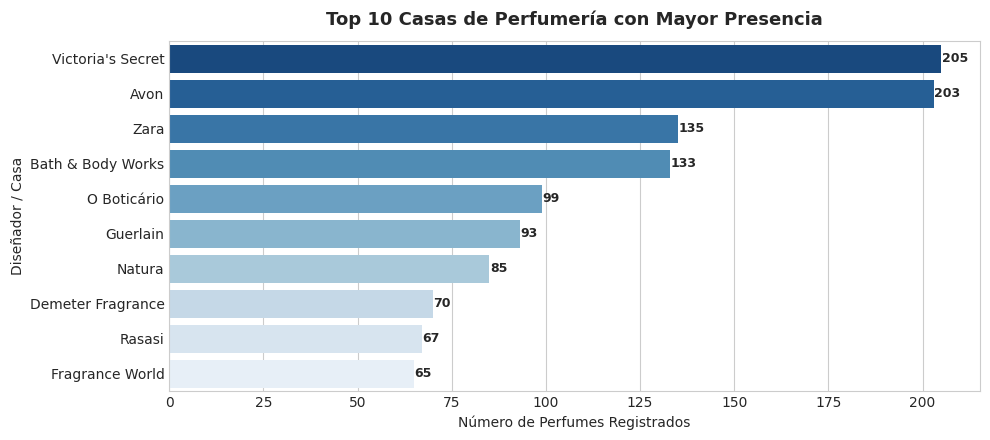

In [11]:
top_designers = df['designer_raw'].value_counts().head(10).reset_index()
top_designers.columns = ['Diseñador / Casa', 'Cantidad de Fragancias']

plt.figure(figsize=(10, 4.5))
ax = sns.barplot(data=top_designers, x='Cantidad de Fragancias', y='Diseñador / Casa', palette='Blues_r')
plt.title('Top 10 Casas de Perfumería con Mayor Presencia', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Número de Perfumes Registrados')
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{int(width)}', (width + 0.1, p.get_y() + p.get_height()/2),
                ha='left', va='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 3. Análisis de Pirámides Olfativas (Salida, Corazón y Fondo)


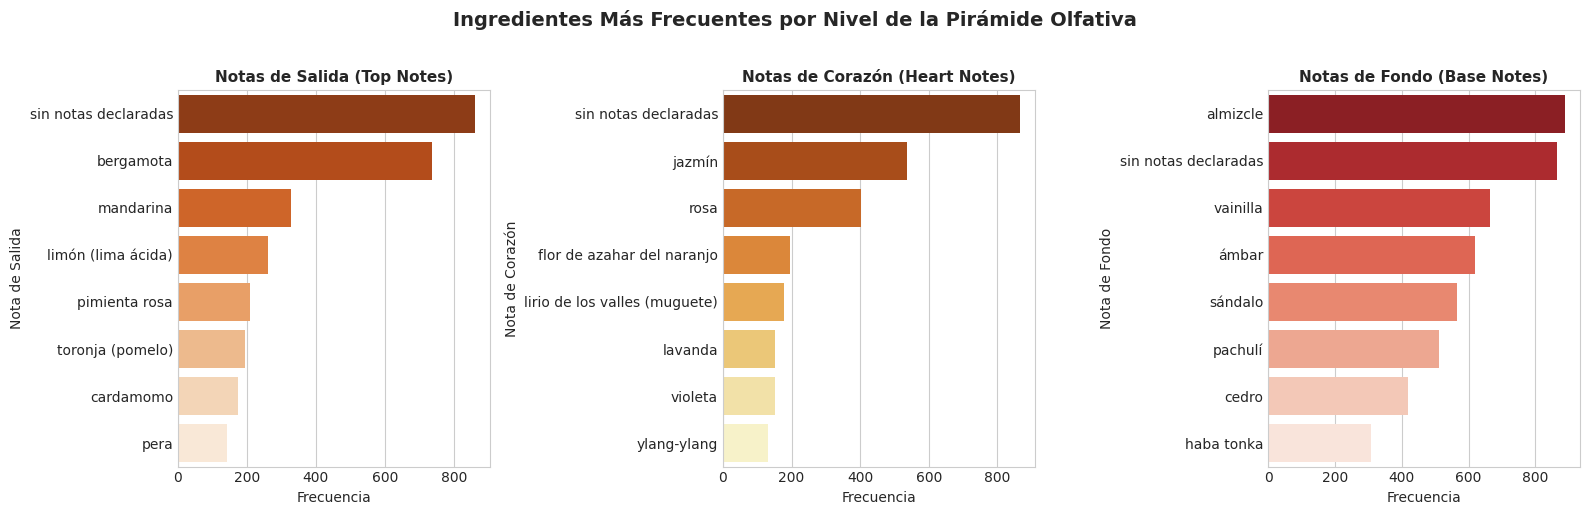

In [12]:
def extract_notes_frequencies(series):
    notes_list = []
    for entry in series.dropna():
        notes = [n.strip().lower() for n in str(entry).split(',') if n.strip()]
        notes_list.extend(notes)
    return Counter(notes_list)

top_freq = extract_notes_frequencies(df_fixed['top_notes_raw'])
heart_freq = extract_notes_frequencies(df_fixed['heart_notes_raw'])
base_freq = extract_notes_frequencies(df_fixed['base_notes_raw'])

df_top_notes = pd.DataFrame(top_freq.most_common(8), columns=['Nota de Salida', 'Frecuencia'])
df_heart_notes = pd.DataFrame(heart_freq.most_common(8), columns=['Nota de Corazón', 'Frecuencia'])
df_base_notes = pd.DataFrame(base_freq.most_common(8), columns=['Nota de Fondo', 'Frecuencia'])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.barplot(data=df_top_notes, x='Frecuencia', y='Nota de Salida', ax=axes[0], palette='Oranges_r')
axes[0].set_title('Notas de Salida (Top Notes)', fontweight='bold', fontsize=11)

sns.barplot(data=df_heart_notes, x='Frecuencia', y='Nota de Corazón', ax=axes[1], palette='YlOrBr_r')
axes[1].set_title('Notas de Corazón (Heart Notes)', fontweight='bold', fontsize=11)

sns.barplot(data=df_base_notes, x='Frecuencia', y='Nota de Fondo', ax=axes[2], palette='Reds_r')
axes[2].set_title('Notas de Fondo (Base Notes)', fontweight='bold', fontsize=11)

plt.suptitle('Ingredientes Más Frecuentes por Nivel de la Pirámide Olfativa', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


---
## 4. Conclusiones y Guía para la Ingeniería de Variables

### Recomendaciones concretas de preprocesamiento:
1. **Estandarización de Notas:** Aplicar tokenización minúscula y eliminación de plurales/sinónimos (ej. *musk* vs *white musk*).
2. **Ponderación de Pirámide Olfativa:** Al construir el corpus TF-IDF, multiplicar la ocurrencia de notas de fondo por **x3** y corazón por **x2**, ya que determinan el secado (*dry down*) real en la piel.
3. **Extracción de Familias Olfativas Dominantes:** Crear columnas categóricas explicativas (*is_sweet, is_woody, is_fresh, is_oriental*) para permitir filtrado rápido en SQL/FastAPI.


amos a construir un pipeline integral que ataca todas las necesidades:Corrección del Error + Tokenización Robusta.Ponderación de Pirámide Olfativa ($3\times$ fondo, $2\times$ corazón, $1\times$ salida).Mapeos Arquetípicos de Personalidad y Estilo (Elegante, Limpio, Liderazgo/Seriedad, Sedactor, Casual).Ingeniería sobre JSONs Sintéticos (Popularidad, Ratio de Aceptación/Controversia, Score de Estación y Hora del Día).Estrategia Óptima para Reviews (Análisis de Sentimiento VADER / DistilBERT + Aspect Extraction).

In [13]:
import pandas as pd
import numpy as np
import json
import ast
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# ==========================================
# PASO 1: MANEJO SEGURO DE LISTAS Y NOTAS
# ==========================================

def safe_eval_list(val):
    """Convierte strings representando listas (ej. "['lemon', 'rose']") a listas reales de Python."""
    if isinstance(val, list):
        return val
    if pd.isna(val) or not val:
        return []
    if isinstance(val, str):
        try:
            parsed = ast.literal_eval(val)
            if isinstance(parsed, list):
                return parsed
        except (ValueError, SyntaxError):
            # Si es un string separado por comas
            return [x.strip() for x in val.split(',') if x.strip()]
    return []

def clean_note(note: str) -> str:
    """Limpia caracteres especiales y estandariza minúsculas."""
    note = str(note).lower().strip()
    note = re.sub(r'[^a-z0-9\s_]', '', note)
    return note.replace(' ', '_')  # Unir n-grams comunes (ej: white_musk)

def create_weighted_corpus(row):
    """Genera el texto con ponderación olfativa de forma segura."""
    top = [clean_note(n) for n in safe_eval_list(row.get('top_notes_raw'))]
    mid = [clean_note(n) for n in safe_eval_list(row.get('heart_notes_raw'))]
    base = [clean_note(n) for n in safe_eval_list(row.get('base_notes_raw'))]
    
    # Si todo está vacío pero existe una columna 'notes' general
    if not (top or mid or base) and 'notes' in row and pd.notna(row['notes']):
        general = [clean_note(n) for n in safe_eval_list(row.get('notes'))]
        return " ".join(general)

    # Multiplicador: Fondo (x3), Corazón (x2), Salida (x1)
    corpus = (top * 1) + (mid * 2) + (base * 3)
    return " ".join(corpus) if corpus else "unknown_note"

# Aplicar a df_fixed
df_fixed['notes_corpus_weighted'] = df_fixed.apply(create_weighted_corpus, axis=1)



In [14]:
df_fixed.head(10)

,url,bottle_image_url,name_raw,designer_raw,global_rating,global_rating_count,top_notes_raw,heart_notes_raw,base_notes_raw,vibe_reactions_raw_dist,reviews_text_corpus,seasons_fixed_dist,time_of_day_fixed_dist,longevity_fixed_dist,sillage_fixed_dist,gender_fixed_dist,price_value_fixed_dist,perfume_id,notes_corpus_weighted
0,https://www.fragrantica.es/perfume/Jean-Paul-G...,https://fimgs.net/mdimg/perfume-thumbs/375x500...,Scandal Jean Paul Gaultier para Mujeres,Jean Paul Gaultier,3.86,"9,804","naranja sanguina, mandarina","miel, gardenia, flor de azahar del naranjo, ja...","cera de abeja, caramelo, pachulí, regaliz","{""me encanta"": ""3.9k"", ""me gusta"": ""3k"", ""me e...",aún conservo unos pocos MLs del original... y ...,"{""invierno"": ""3.7k"", ""verano"": ""778"", ""otoño"":...","{""día"": ""2.1k"", ""noche"": ""3.6k""}","{""escasa"": ""66"", ""débil"": ""233"", ""moderada"": ""...","{""moderada"": ""1.7k"", ""suave"": ""295"", ""pesada"":...","{""femenino"": ""3.2k"", ""unisex femenino"": ""343"",...","{""extremadamente costoso"": ""170"", ""ligeramente...",1496,naranja_sanguina mandarina miel gardenia flor_...
1,https://www.fragrantica.es/perfume/Elizabeth-A...,https://fimgs.net/mdimg/perfume-thumbs/375x500...,Pretty Elizabeth Arden para Mujeres,Elizabeth Arden,3.77,"1,153","flor de azahar del naranjo, mandarina, durazno...","peonía, jazmín, azucena, iris","almizcle, notas amaderadas, ámbar","{""me encanta"": ""260"", ""me gusta"": ""594"", ""me e...",Es un perfume que uso desde el 2010 y entre mi...,"{""invierno"": ""55"", ""verano"": ""290"", ""otoño"": ""...","{""día"": ""495"", ""noche"": ""62""}","{""escasa"": ""44"", ""débil"": ""79"", ""moderada"": ""1...","{""moderada"": ""181"", ""suave"": ""137"", ""pesada"": ...","{""femenino"": ""178"", ""unisex femenino"": ""18"", ""...","{""extremadamente costoso"": ""4"", ""ligeramente c...",987,flor_de_azahar_del_naranjo mandarina durazno_m...
2,https://www.fragrantica.es/perfume/Dior/Dior-A...,https://fimgs.net/mdimg/perfume-thumbs/375x500...,Dior Addict Shine Dior para Mujeres,Dior,4.07,"1,120",Sin notas declaradas,Sin notas declaradas,Sin notas declaradas,"{""me encanta"": ""379"", ""me gusta"": ""584"", ""me e...",Amé este perfume! Hace años no lo consigo! Per...,"{""invierno"": ""60"", ""verano"": ""344"", ""otoño"": ""...","{""día"": ""451"", ""noche"": ""73""}","{""escasa"": ""18"", ""débil"": ""49"", ""moderada"": ""1...","{""moderada"": ""152"", ""suave"": ""54"", ""pesada"": ""...","{""femenino"": ""88"", ""unisex femenino"": ""5"", ""un...","{""extremadamente costoso"": ""5"", ""ligeramente c...",890,sin_notas_declaradas sin_notas_declaradas sin_...
3,https://www.fragrantica.es/perfume/Granado/San...,https://fimgs.net/mdimg/perfume-thumbs/375x500...,Sândalo e Cardamomo Granado para Hombres y Muj...,Granado,3.54,145,"cardamomo, semillas de zanahoria, hojas de vio...","cachemira, vetiver, vainilla","sándalo, almizcle, cedro","{""me encanta"": ""45"", ""me gusta"": ""41"", ""me es ...",NaN,"{""invierno"": ""43"", ""verano"": ""19"", ""otoño"": ""61""}","{""día"": ""57"", ""noche"": ""54""}","{""escasa"": ""1"", ""débil"": ""8"", ""moderada"": ""34""...","{""moderada"": ""34"", ""suave"": ""19"", ""pesada"": ""3...","{""femenino"": ""1"", ""unisex femenino"": ""3"", ""uni...","{""extremadamente costoso"": ""0"", ""ligeramente c...",1254,cardamomo semillas_de_zanahoria hojas_de_viole...
4,https://www.fragrantica.es/perfume/Yves-Saint-...,https://fimgs.net/mdimg/perfume-thumbs/375x500...,Kouros Cologne Sport Eau d'Ete Summer Fragranc...,Yves Saint Laurent,4.14,42,"menta, bergamota","lavanda, jazmín","ámbar blanco, cedro","{""me encanta"": ""19"", ""me gusta"": ""17"", ""me es ...","Siempre me ha encantado Kouros, es elegancia y...","{""invierno"": ""4"", ""verano"": ""16"", ""otoño"": ""8""}","{""día"": ""11"", ""noche"": ""7""}","{""escasa"": ""0"", ""débil"": ""4"", ""moderada"": ""8"",...","{""moderada"": ""8"", ""suave"": ""5"", ""pesada"": ""12""...","{""femen

In [15]:
# Obtenemos los valores distintos de notes_corpus_weighted para verificar la diversidad de notas
df_fixed['notes_corpus_weighted'].unique() 


array(['naranja_sanguina mandarina miel gardenia flor_de_azahar_del_naranjo jazmn durazno_melocotn miel gardenia flor_de_azahar_del_naranjo jazmn durazno_melocotn cera_de_abeja caramelo pachul regaliz cera_de_abeja caramelo pachul regaliz cera_de_abeja caramelo pachul regaliz',
       'flor_de_azahar_del_naranjo mandarina durazno_melocotn peona jazmn azucena iris peona jazmn azucena iris almizcle notas_amaderadas mbar almizcle notas_amaderadas mbar almizcle notas_amaderadas mbar',
       'sin_notas_declaradas sin_notas_declaradas sin_notas_declaradas sin_notas_declaradas sin_notas_declaradas sin_notas_declaradas',
       ...,
       'jengibre bergamota violeta albahaca pimienta_blanca violeta albahaca pimienta_blanca haba_tonka vetiver_de_tahit almizcle cedro haba_tonka vetiver_de_tahit almizcle cedro haba_tonka vetiver_de_tahit almizcle cedro',
       'rosa jazmn notas_verdes manzana cereza_cida_guinda flor_de_azahar_del_naranjo manzana cereza_cida_guinda flor_de_azahar_del_naranjo al

In [16]:
df_fixed.head(10)

,url,bottle_image_url,name_raw,designer_raw,global_rating,global_rating_count,top_notes_raw,heart_notes_raw,base_notes_raw,vibe_reactions_raw_dist,reviews_text_corpus,seasons_fixed_dist,time_of_day_fixed_dist,longevity_fixed_dist,sillage_fixed_dist,gender_fixed_dist,price_value_fixed_dist,perfume_id,notes_corpus_weighted
0,https://www.fragrantica.es/perfume/Jean-Paul-G...,https://fimgs.net/mdimg/perfume-thumbs/375x500...,Scandal Jean Paul Gaultier para Mujeres,Jean Paul Gaultier,3.86,"9,804","naranja sanguina, mandarina","miel, gardenia, flor de azahar del naranjo, ja...","cera de abeja, caramelo, pachulí, regaliz","{""me encanta"": ""3.9k"", ""me gusta"": ""3k"", ""me e...",aún conservo unos pocos MLs del original... y ...,"{""invierno"": ""3.7k"", ""verano"": ""778"", ""otoño"":...","{""día"": ""2.1k"", ""noche"": ""3.6k""}","{""escasa"": ""66"", ""débil"": ""233"", ""moderada"": ""...","{""moderada"": ""1.7k"", ""suave"": ""295"", ""pesada"":...","{""femenino"": ""3.2k"", ""unisex femenino"": ""343"",...","{""extremadamente costoso"": ""170"", ""ligeramente...",1496,naranja_sanguina mandarina miel gardenia flor_...
1,https://www.fragrantica.es/perfume/Elizabeth-A...,https://fimgs.net/mdimg/perfume-thumbs/375x500...,Pretty Elizabeth Arden para Mujeres,Elizabeth Arden,3.77,"1,153","flor de azahar del naranjo, mandarina, durazno...","peonía, jazmín, azucena, iris","almizcle, notas amaderadas, ámbar","{""me encanta"": ""260"", ""me gusta"": ""594"", ""me e...",Es un perfume que uso desde el 2010 y entre mi...,"{""invierno"": ""55"", ""verano"": ""290"", ""otoño"": ""...","{""día"": ""495"", ""noche"": ""62""}","{""escasa"": ""44"", ""débil"": ""79"", ""moderada"": ""1...","{""moderada"": ""181"", ""suave"": ""137"", ""pesada"": ...","{""femenino"": ""178"", ""unisex femenino"": ""18"", ""...","{""extremadamente costoso"": ""4"", ""ligeramente c...",987,flor_de_azahar_del_naranjo mandarina durazno_m...
2,https://www.fragrantica.es/perfume/Dior/Dior-A...,https://fimgs.net/mdimg/perfume-thumbs/375x500...,Dior Addict Shine Dior para Mujeres,Dior,4.07,"1,120",Sin notas declaradas,Sin notas declaradas,Sin notas declaradas,"{""me encanta"": ""379"", ""me gusta"": ""584"", ""me e...",Amé este perfume! Hace años no lo consigo! Per...,"{""invierno"": ""60"", ""verano"": ""344"", ""otoño"": ""...","{""día"": ""451"", ""noche"": ""73""}","{""escasa"": ""18"", ""débil"": ""49"", ""moderada"": ""1...","{""moderada"": ""152"", ""suave"": ""54"", ""pesada"": ""...","{""femenino"": ""88"", ""unisex femenino"": ""5"", ""un...","{""extremadamente costoso"": ""5"", ""ligeramente c...",890,sin_notas_declaradas sin_notas_declaradas sin_...
3,https://www.fragrantica.es/perfume/Granado/San...,https://fimgs.net/mdimg/perfume-thumbs/375x500...,Sândalo e Cardamomo Granado para Hombres y Muj...,Granado,3.54,145,"cardamomo, semillas de zanahoria, hojas de vio...","cachemira, vetiver, vainilla","sándalo, almizcle, cedro","{""me encanta"": ""45"", ""me gusta"": ""41"", ""me es ...",NaN,"{""invierno"": ""43"", ""verano"": ""19"", ""otoño"": ""61""}","{""día"": ""57"", ""noche"": ""54""}","{""escasa"": ""1"", ""débil"": ""8"", ""moderada"": ""34""...","{""moderada"": ""34"", ""suave"": ""19"", ""pesada"": ""3...","{""femenino"": ""1"", ""unisex femenino"": ""3"", ""uni...","{""extremadamente costoso"": ""0"", ""ligeramente c...",1254,cardamomo semillas_de_zanahoria hojas_de_viole...
4,https://www.fragrantica.es/perfume/Yves-Saint-...,https://fimgs.net/mdimg/perfume-thumbs/375x500...,Kouros Cologne Sport Eau d'Ete Summer Fragranc...,Yves Saint Laurent,4.14,42,"menta, bergamota","lavanda, jazmín","ámbar blanco, cedro","{""me encanta"": ""19"", ""me gusta"": ""17"", ""me es ...","Siempre me ha encantado Kouros, es elegancia y...","{""invierno"": ""4"", ""verano"": ""16"", ""otoño"": ""8""}","{""día"": ""11"", ""noche"": ""7""}","{""escasa"": ""0"", ""débil"": ""4"", ""moderada"": ""8"",...","{""moderada"": ""8"", ""suave"": ""5"", ""pesada"": ""12""...","{""femen

In [17]:

# ==========================================
# PASO 2: MAPEOS ARQUETÍPICOS (PERSONALIDAD)
# ==========================================

# Mapeos Arquetípicos Binarios en Español
ARCHETYPES = {
    'is_elegant': ['iris', 'cuero', 'sandalo', 'ambar', 'rosa', 'vetiver'],
    'is_clean': ['almizcle', 'almizcle_blanco', 'lavanda', 'aldehido', 'neroli', 'bergamota'],
    'is_leadership_boss': ['tabaco', 'oud', 'cedro', 'cuero', 'incienso'],
    'is_seductive': ['vainilla', 'habatonka', 'haba_tonka', 'ambar', 'canela', 'praline'],
    'is_fresh_casual': ['limon', 'citricos', 'menta', 'notas_acuaticas', 'manzana']
}

for archetype, keywords in ARCHETYPES.items():
    df_fixed[archetype] = df_fixed['notes_corpus_weighted'].apply(
        lambda corpus: int(any(kw in corpus for kw in keywords))
    )


# ==========================================
# PASO 3: INGENIERÍA DE DATOS
# ==========================================

def parse_count(val) -> float:
    if isinstance(val, (int, float)):
        return float(val)
    if isinstance(val, str):
        val = val.lower().replace('"', '').strip()
        if 'k' in val:
            return float(val.replace('k', '')) * 1000
        try:
            return float(val)
        except ValueError:
            return 0.0
    return 0.0

def process_synthetic_metrics(row):
    # Parse JSONs
    try:
        vibes = json.loads(row['vibe_reactions_raw_dist']) if isinstance(row['vibe_reactions_raw_dist'], str) else {}
        seasons = json.loads(row['seasons_fixed_dist']) if isinstance(row['seasons_fixed_dist'], str) else {}
        tod = json.loads(row['time_of_day_fixed_dist']) if isinstance(row['time_of_day_fixed_dist'], str) else {}
    except Exception:
        vibes, seasons, tod = {}, {}, {}


        #{"me encanta": "3.9k", "me gusta": "3k", "me es indiferente": "963", "no me gusta": "1.6k", "la odio": "382"}

    # 1. Total Engagement y Popularidad
    love = parse_count(vibes.get('me encanta', 0))
    like = parse_count(vibes.get('me gusta', 0))
    ok = parse_count(vibes.get('me es indiferente', 0))
    dislike = parse_count(vibes.get('no me gusta', 0))
    hate = parse_count(vibes.get('la odio', 0))
    
    total_votes = love + like + ok + dislike + hate
    positives = love + like
    negatives = dislike + hate
    
    # Métricas clave
    satisfaction_rate = (positives / total_votes) if total_votes > 0 else 0.5
    controversy_index = (negatives / total_votes) if total_votes > 0 else 0.0
    
    # 2. Season Dominante
    parsed_seasons = {k: parse_count(v) for k, v in seasons.items()}
    best_season = max(parsed_seasons, key=parsed_seasons.get) if parsed_seasons else 'versatile'
    
    # 3. Day / Night Ratio (1.0 = Día puro, 0.0 = Noche pura) {"día": "11", "noche": "7"}
    day = parse_count(tod.get('día', 0))
    night = parse_count(tod.get('noche', 0))
    day_ratio = day / (day + night) if (day + night) > 0 else 0.5

    return pd.Series({
        'total_votes': total_votes,
        'satisfaction_rate': satisfaction_rate,
        'controversy_index': controversy_index,
        'best_season': best_season,
        'day_ratio': day_ratio
    })

synthetic_feats = df_fixed.apply(process_synthetic_metrics, axis=1)
df_fixed = pd.concat([df_fixed, synthetic_feats], axis=1)


# ==========================================
# PASO 4: VECTORIZACIÓN Y TF-IDF
# ==========================================

tfidf = TfidfVectorizer(min_df=1, token_pattern=r'(?u)\b\w+\b')
tfidf_matrix = tfidf.fit_transform(df_fixed['notes_corpus_weighted'])

In [18]:
df_fixed.head(10)

,url,bottle_image_url,name_raw,designer_raw,global_rating,global_rating_count,top_notes_raw,heart_notes_raw,base_notes_raw,vibe_reactions_raw_dist,...,is_elegant,is_clean,is_leadership_boss,is_seductive,is_fresh_casual,total_votes,satisfaction_rate,controversy_index,best_season,day_ratio
0,https://www.fragrantica.es/perfume/Jean-Paul-G...,https://fimgs.net/mdimg/perfume-thumbs/375x500...,Scandal Jean Paul Gaultier para Mujeres,Jean Paul Gaultier,3.86,"9,804","naranja sanguina, mandarina","miel, gardenia, flor de azahar del naranjo, ja...","cera de abeja, caramelo, pachulí, regaliz","{""me encanta"": ""3.9k"", ""me gusta"": ""3k"", ""me e...",...,0,0,0,0,0,9845.0,0.700863,0.201320,invierno,0.368421
1,https://www.fragrantica.es/perfume/Elizabeth-A...,https://fimgs.net/mdimg/perfume-thumbs/375x500...,Pretty Elizabeth Arden para Mujeres,Elizabeth Arden,3.77,"1,153","flor de azahar del naranjo, mandarina, durazno...","peonía, jazmín, azucena, iris","almizcle, notas amaderadas, ámbar","{""me encanta"": ""260"", ""me gusta"": ""594"", ""me e...",...,1,1,0,0,0,1153.0,0.740676,0.191674,verano,0.888689
2,https://www.fragrantica.es/perfume/Dior/Dior-A...,https://fimgs.net/mdimg/perfume-thumbs/375x500...,Dior Addict Shine Dior para Mujeres,Dior,4.07,"1,120",Sin notas declaradas,Sin notas declaradas,Sin notas declaradas,"{""me encanta"": ""379"", ""me gusta"": ""584"", ""me e...",...,0,0,0,0,0,1120.0,0.859821,0.125000,verano,0.860687
3,https://www.fragrantica.es/perfume/Granado/San...,https://fimgs.net/mdimg/perfume-thumbs/375x500...,Sândalo e Cardamomo Granado para Hombres y Muj...,Granado,3.54,145,"cardamomo, semillas de zanahoria, hojas de vio...","cachemira, vetiver, vainilla","sándalo, almizcle, cedro","{""me encanta"": ""45"", ""me gusta"": ""41"", ""me es ...",...,1,1,1,1,0,145.0,0.593103,0.275862,otoño,0.513514
4,https://www.fragrantica.es/perfume/Yves-Saint-...,https://fimgs.net/mdimg/perfume-thumbs/375x500...,Kouros Cologne Sport Eau d'Ete Summer Fragranc...,Yves Saint Laurent,4.14,42,"menta, bergamota","lavanda, jazmín","ámbar blanco, cedro","{""me encanta"": ""19"", ""me gusta"": ""17"", ""me es ...",...,0,1,1,0,1,42.0,0.857143,0.119048,verano,0.611111
5,https://www.fragrantica.es/perfume/Fragrance-W...,https://fimgs.net/mdimg/perfume-thumbs/375x500...,Little Black Dress Fragrance World para Mujeres,Fragrance World,4.00,6,"té negro, bayas rojas, bergamota",rosa negra,"haba tonka, almendra","{""me encanta"": ""3"", ""me gusta"": ""2"", ""me es in...",...,1,1,0,1,0,6.0,0.833333,0.166667,otoño,0.500000
6,https://www.fragrantica.es/perfume/Bath-Body-W...,https://fimgs.net/mdimg/perfume-thumbs/375x500...,Fresh Vanilla Blossoms Bath & Body Works para ...,Bath & Body Works,4.30,236,Sin notas declaradas,Sin notas declaradas,Sin notas declaradas,"{""me encanta"": ""122"", ""me gusta"": ""81"", ""me es...",...,0,0,0,0,0,236.0,0.860169,0.067797,otoño,0.715232
7,https://www.fragrantica.es/perfume/Natura/Humo...,https://fimgs.net/mdimg/perfume-thumbs/375x500...,Humor no Ar Natura para Mujeres,Natura,4.12,137,"manzana, ciruela, níspero japonés, nuez moscad...","coñac, lirio de los valles (muguete), fresia, ...","vainilla, ámbar, haba tonka, sándalo, benjuí, ...","{""me encanta"": ""53"", ""me gusta"": ""64"", ""me es ...",...,1,1,1,1,1,137.0,0.854015,0.109489,otoño,0.781609
8,https://www.fragrantica.es/perfume/Arabiyat-Pr...,https://fimgs.net/mdimg/perfume-thumbs/375x500...,Portrait Café Noir Arabiyat Prestige para Homb...,Arabiyat Prestige,5.00,7,"bergamota, grosellas negras","Akigalawood, pachulí, caramelo","Evernil, ámbar, almizcle","{""me encanta"": ""7"", ""me gusta"": ""0"", ""me es in...",...,0,1,0,0,0,7.0,1.000000,0.000000,verano,0.600000
9,https://www.fragrantica.es/perfume/Comme-des-G...,https://fimgs.net/mdimg/perfume-thumbs/375x500...,Ganja Comme des Garcons para Hombres y Mujeres,Comme des Garcons,3.86,258,"comino, pimienta negra","marihuana (cannabis), yerba mate, resina almác...","pachulí, madera de gaiac, incienso de olíbano 

Esta función combina el vector de notas (TF-IDF), la simetría de arquetipos y el filtrado por estación o momento del día.

In [19]:
def recommend_perfumes(
    perfume_id: int, 
    df: pd.DataFrame, 
    tfidf_mat, 
    top_n: int = 5,
    filter_season: str = None,
    must_have_archetype: str = None,
    min_satisfaction: float = 0.60
):
    """
    Sistema de recomendación híbrido basado en contenido con filtros de negocio.
    """
    # 1. Mapeo de índice
    idx = df.index[df['id'] == perfume_id].tolist()
    if not idx:
        raise ValueError(f"El ID {perfume_id} no se encuentra en el dataset.")
    idx = idx[0]

    # 2. Cosine Similarity Olfativo
    cosine_sim = cosine_similarity(tfidf_mat[idx], tfidf_mat).flatten()
    
    # Crear copie de trabajo con scores
    scores_df = df.copy()
    scores_df['similarity_score'] = cosine_sim

    # Excluir el mismo perfume
    scores_df = scores_df[scores_df.index != idx]

    # 3. Filtros de Calidad y Negocio (Hard Filters)
    scores_df = scores_df[scores_df['satisfaction_rate'] >= min_satisfaction]

    if filter_season:
        scores_df = scores_df[scores_df['best_season'] == filter_season]

    if must_have_archetype and must_have_archetype in df.columns:
        scores_df = scores_df[scores_df[must_have_archetype] == 1]

    # 4. Ajuste del Score Final (Boost por coincidencias de arquetipo)
    target_archetypes = ['is_elegant', 'is_clean', 'is_leadership_boss', 'is_seductive', 'is_fresh_casual']
    target_vector = df.loc[idx, target_archetypes].values.astype(int)
    
    # Bonus si comparte la misma 'vibración'
    archetype_sim = (scores_df[target_archetypes].values @ target_vector) / len(target_archetypes)
    scores_df['final_score'] = (scores_df['similarity_score'] * 0.70) + (archetype_sim * 0.30)

    # Ordenar y retornar top_n
    recommended = scores_df.sort_values(by='final_score', ascending=False)
    
    cols_to_show = ['id', 'name', 'final_score', 'similarity_score', 'best_season', 'satisfaction_rate']
    present_cols = [c for c in cols_to_show if c in recommended.columns]
    
    return recommended[present_cols].head(top_n)

In [20]:
# 1. Crear un DataFrame de prueba con datos simulados
data_demo = {
    'id': [1, 2, 3, 4, 5],
    'name': ['Bleu Elegance', 'Vanilla Night', 'Citrus Breeze', 'Oud Executive', 'Clean Cotton'],
    'top_notes': ["['lemon', 'bergamot']", "['vanilla', 'cinnamon']", "['lemon', 'mint']", "['spices', 'incense']", "['aldehyde', 'bergamot']"],
    'heart_notes': ["['iris', 'cedar']", "['tonka_bean', 'amber']", "['aquatic_notes']", "['leather', 'oud']", "['lavender', 'white_musk']"],
    'base_notes': ["['sandalwood', 'vetiver']", "['praline', 'chocolate']", "['cedar']", "['tobacco', 'vetiver']", "['musk', 'soapy_notes']"],
    'vibe_reactions_raw_dist': ['{"love": "10k", "like": "2k", "ok": "500", "dislike": "100", "hate": "50"}'] * 5,
    'seasons_raw_dist': ['{"winter": "1k", "spring": "3k", "summer": "5k", "fall": "2k"}'] * 5,
    'time_of_day_raw_dist': ['{"day": "3k", "night": "1k"}'] * 5
}

df_fixed_demo = pd.DataFrame(data_demo)

# Preprocesar datos usando el pipeline anterior
df_fixed_demo['notes_corpus_weighted'] = df_fixed_demo.apply(create_weighted_corpus, axis=1)

for archetype, keywords in ARCHETYPES.items():
    df_fixed_demo[archetype] = df_fixed_demo['notes_corpus_weighted'].apply(
        lambda corpus: int(any(kw in corpus for kw in keywords))
    )

synthetic_feats = df_fixed_demo.apply(process_synthetic_metrics, axis=1)
df_fixed_demo = pd.concat([df_fixed_demo, synthetic_feats], axis=1)

tfidf = TfidfVectorizer(min_df=1, token_pattern=r'(?u)\b\w+\b')
tfidf_matrix = tfidf.fit_transform(df_fixed_demo['notes_corpus_weighted'])

# 2. Ejecutar la recomendación
# Caso de uso: El usuario está viendo 'Bleu Elegance' (id=1) y quiere algo similar pero para estilo 'Elegante/Liderazgo'
recomendaciones = recommend_perfumes(
    perfume_id=1,
    df=df_fixed_demo,
    tfidf_mat=tfidf_matrix,
    top_n=3,
    must_have_archetype='is_leadership_boss'
)

print(recomendaciones)

Empty DataFrame
Columns: [id, name, final_score, similarity_score, best_season, satisfaction_rate]
Index: []


#### PROCESAMIENTO E INTEGRACION DE REVIEWS

Plan de Procesamiento Recomendado:
Aspect-Based Sentiment Analysis (ABSA):
No hagas un análisis de sentimiento global a toda la review. Un usuario puede decir: "Huele increíble (positivo), pero dura 10 minutos (negativo)".

Extrae entidades clave: duración, estela/proyección, cumplidos, precio/calidad.

Calcula el Perfume Performance Index (PPI):
A partir de las menciones procesadas de las reviews, genera 3 columnas sintéticas de alta precisión:

longevity_score: Frecuencia y sentimiento cuando se menciona "duration", "hours", "lasts".

sillage_score: Frecuencia cuando se menciona "projection", "skin scent", "filling the room".

compliment_factor: Ratio de menciones positivas sobre "compliments", "head turner", "sexy".

Inclusión en el Modelo:
Usa estos scores extraídos de las reviews para aplicar Re-Ranking en la función de recomendación: si el usuario pide "perfume elegante para eventos de noche", la función multiplicará el score por sillage_score y longevity_score.

In [21]:
import pandas as pd
import numpy as np
import re

# ==============================================================================
# 1. LÉXICO AMPLIADO EN ESPAÑOL (Menciones explícitas e implícitas)
# ==============================================================================
ASPECT_LEXICON_ES = {
    'longevity': {
        'keywords': [
            'duracion', 'durabilidad', 'dura', 'durar', 'fijacion', 'fija', 
            'longevidad', 'horas', 'longevo', 'desempeno', 'performance', 'pellejo'
        ],
        'positives': [
            'excelente', 'bestia', 'barbaridad', 'eterna', 'mucho', 'increible', 
            'buena', '10/10', 'mucha', 'eterno', 'duradero', 'todo el dia', 'sobrado'
        ],
        'negatives': [
            'nada', 'poco', 'debil', 'pobre', 'mala', 'desaparece', 'suspiro', 
            'escasa', 'cero', 'agua', 'mediocre', 'efimero', 'no se siente'
        ]
    },
    'sillage': {
        'keywords': [
            'estela', 'proyeccion', 'proyecta', 'alcance', 'proyectar', 'presencia',
            'se siente', 'distancia', 'estelar'
        ],
        'positives': [
            'enorme', 'pesada', 'potente', 'llena', 'habitacion', 'mucha', 'fuerte', 
            'monstruosa', 'bestial', 'marcada', 'pesado', 'notable'
        ],
        'negatives': [
            'pobre', 'intima', 'baja', 'cerca', 'piel', 'suave', 'nula', 'inexistente',
            'ras de piel', 'timida', 'debil'
        ]
    },
    'compliments': {
        'keywords': [
            'cumplido', 'cumplidos', 'halago', 'halagos', 'elogio', 'elogios', 
            'chulearon', 'preguntaron', 'preguntan', 'gusta a todos', 'encanta a', 
            'llamo la atencion', 'me dijeron', 'te dicen', 'atractivo', 'sexy', 'reacciones'
        ],
        'positives': [
            'muchos', 'siempre', 'reacciones', 'asegurados', 'chulean', 'voltear', 
            'cabezas', 'llueven', 'garantizados', 'increible', 'encanta', 'fascinados'
        ],
        'negatives': [
            'ninguno', 'nadie', 'cero', 'sin', 'ningun', 'feo', 'disgusto', 'desagrada'
        ]
    }
}

# Compilación de patrones Regex
COMPILED_PATTERNS = {}
for aspect, lexicon in ASPECT_LEXICON_ES.items():
    COMPILED_PATTERNS[aspect] = {
        'kw': re.compile(r'\b(' + '|'.join(lexicon['keywords']) + r')\b', re.IGNORECASE),
        'pos': re.compile(r'\b(' + '|'.join(lexicon['positives']) + r')\b', re.IGNORECASE),
        'neg': re.compile(r'\b(' + '|'.join(lexicon['negatives']) + r')\b', re.IGNORECASE)
    }


# ==============================================================================
# 2. FUNCIÓN DE EXTRACCIÓN DE ASPECTOS POR REVIEW
# ==============================================================================
def process_reviews_expanded(df: pd.DataFrame, text_column: str = 'review_text') -> pd.DataFrame:
    """Extrae scores por reseña usando asignación inteligente de NaNs."""
    # Limpieza de acentos vectorizada
    cleaned_series = (
        df[text_column]
        .astype(str)
        .str.lower()
        .str.replace(r'[áàäâ]', 'a', regex=True)
        .str.replace(r'[éèëê]', 'e', regex=True)
        .str.replace(r'[íìïî]', 'i', regex=True)
        .str.replace(r'[óòöô]', 'o', regex=True)
        .str.replace(r'[úùüû]', 'u', regex=True)
    )

    results = pd.DataFrame(index=df.index)

    for aspect, patterns in COMPILED_PATTERNS.items():
        has_aspect = cleaned_series.str.contains(patterns['kw'], regex=True)

        pos_counts = cleaned_series.str.findall(patterns['pos']).str.len()
        neg_counts = cleaned_series.str.findall(patterns['neg']).str.len()
        total_modifiers = pos_counts + neg_counts

        # Cálculo de Score:
        # Si NO menciona el aspecto -> np.nan (No ensucia el promedio con ceros)
        # Si menciona el aspecto pero no hay modificadores claros -> 0.1 (Neutro leve)
        # Si hay modificadores -> (Pos - Neg) / Total
        score = np.where(
            ~has_aspect,
            np.nan,
            np.where(
                total_modifiers > 0,
                (pos_counts - neg_counts) / total_modifiers,
                0.1
            )
        )

        results[f'{aspect}_score'] = np.round(score, 2)

    return results


# ==============================================================================
# 3. AGREGACIÓN BAYESIANA PONDERADA POR PERFUME
# ==============================================================================
def calculate_bayesian_perfume_scores(reviews_df: pd.DataFrame, aspect_scores_df: pd.DataFrame, min_mencions_weight: int = 3) -> pd.DataFrame:
    """
    Agrupa por perfume y calcula un Promedio Bayesiano para suavizar la distribución.
    """
    df_combined = pd.concat([reviews_df[['perfume_id']], aspect_scores_df], axis=1)

    perfume_metrics = {}
    
    for aspect in ['longevity_score', 'sillage_score', 'compliments_score']:
        # Media global del aspecto (excluyendo NaNs)
        global_mean = df_combined[aspect].mean()
        if pd.isna(global_mean):
            global_mean = 0.0

        # Agregación por perfume (Cuenta menciones reales y calcula el promedio crudo)
        grouped = df_combined.groupby('perfume_id')[aspect].agg(['count', 'mean']).reset_index()

        # Fórmula Bayesiana: (n * mean + m * global_mean) / (n + m)
        # n = número de reviews que mencionan el aspecto
        # m = peso mínimo de suavizado (m menciones virtuales)
        n = grouped['count']
        mean = grouped['mean'].fillna(global_mean)
        m = min_mencions_weight

        bayesian_score = (n * mean + m * global_mean) / (n + m)
        grouped[f'{aspect}_bayesian'] = np.round(bayesian_score, 3)

        perfume_metrics[aspect] = grouped[['perfume_id', f'{aspect}_bayesian']]

    # Unir los 3 aspectos en un único DataFrame final por perfume
    final_perfume_df = perfume_metrics['longevity_score']
    final_perfume_df = final_perfume_df.merge(perfume_metrics['sillage_score'], on='perfume_id')
    final_perfume_df = final_perfume_df.merge(perfume_metrics['compliments_score'], on='perfume_id')

    return final_perfume_df


# ==============================================================================
# 4. EJECUCIÓN DEL PIPELINE COMPLETO
# ==============================================================================

reviews_demo = df_fixed[['perfume_id', 'reviews_text_corpus']].copy()

# 1. Procesar reviews individuales
aspect_scores = process_reviews_expanded(reviews_demo, text_column='reviews_text_corpus')

# 2. Calcular los scores finales suavizados para los perfumes
perfume_performance_df = calculate_bayesian_perfume_scores(reviews_demo, aspect_scores)

print("--- METRICAS CORREGIDAS Y SUAVIZADAS (DISTRIBUCIÓN CONTINUA) ---")
print(perfume_performance_df)

--- METRICAS CORREGIDAS Y SUAVIZADAS (DISTRIBUCIÓN CONTINUA) ---
      perfume_id  longevity_score_bayesian  sillage_score_bayesian  \
0              0                     0.044                  -0.292   
1              1                     0.045                  -0.387   
2              2                     0.100                  -0.219   
3              3                     0.023                  -0.344   
4              4                     0.033                  -0.194   
...          ...                       ...                     ...   
3011        3011                     0.044                  -0.469   
3012        3012                     0.044                  -0.292   
3013        3013                     0.044                  -0.292   
3014        3014                     0.044                  -0.292   
3015        3015                     0.044                  -0.292   

      compliments_score_bayesian  
0                         -0.177  
1                       

In [22]:
## estadisticos de performance_df
perfomance_stats = perfume_performance_df[['longevity_score_bayesian', 'sillage_score_bayesian', 'compliments_score_bayesian']].describe().round(3)
print("\n--- ESTADÍSTICOS DESCRIPTIVOS DE METRICAS ---")
print(perfomance_stats)


--- ESTADÍSTICOS DESCRIPTIVOS DE METRICAS ---
       longevity_score_bayesian  sillage_score_bayesian  \
count                  3016.000                3016.000   
mean                      0.044                  -0.292   
std                       0.081                   0.090   
min                      -0.217                  -0.469   
25%                       0.044                  -0.292   
50%                       0.044                  -0.292   
75%                       0.044                  -0.292   
max                       0.283                   0.031   

       compliments_score_bayesian  
count                    3016.000  
mean                       -0.177  
std                         0.052  
min                        -0.382  
25%                        -0.177  
50%                        -0.177  
75%                        -0.177  
max                         0.118  



Número de valores únicos para cada métrica:
Longevidad: 113, Estela: 67, Halagos: 47
Valores unicos de cada métrica:
Longevidad: [ 0.044  0.045  0.1    0.023  0.033  0.05   0.075  0.115  0.128  0.068
 -0.217 -0.062  0.005  0.2    0.145  0.083  0.283 -0.092 -0.05   0.058
  0.095 -0.017  0.003 -0.035 -0.032  0.15   0.01  -0.155 -0.08   0.06
  0.123 -0.012 -0.04   0.168  0.055  0.048  0.14   0.158  0.233 -0.135
 -0.127  0.228  0.21   0.043  0.015 -0.117 -0.145  0.013  0.22  -0.06
  0.135  0.063 -0.01  -0.175  0.193  0.165  0.053  0.008 -0.075  0.183
 -0.085  0.238 -0.002 -0.167  0.09  -0.03   0.105 -0.067  0.088 -0.007
 -0.102  0.133 -0.015 -0.157  0.208  0.223  0.018 -0.11  -0.025 -0.107
 -0.087  0.173 -0.14  -0.065  0.108  0.02  -0.07  -0.042 -0.027  0.098
  0.073 -0.15   0.24  -0.122 -0.022  0.143  0.188  0.203 -0.162  0.163
 -0.077 -0.09   0.175 -0.1    0.078  0.125 -0.185  0.253  0.248 -0.037
 -0.13   0.205 -0.082]
Estela: [-0.292 -0.387 -0.219 -0.344 -0.194 -0.302 -0.079 -0.269 -0.

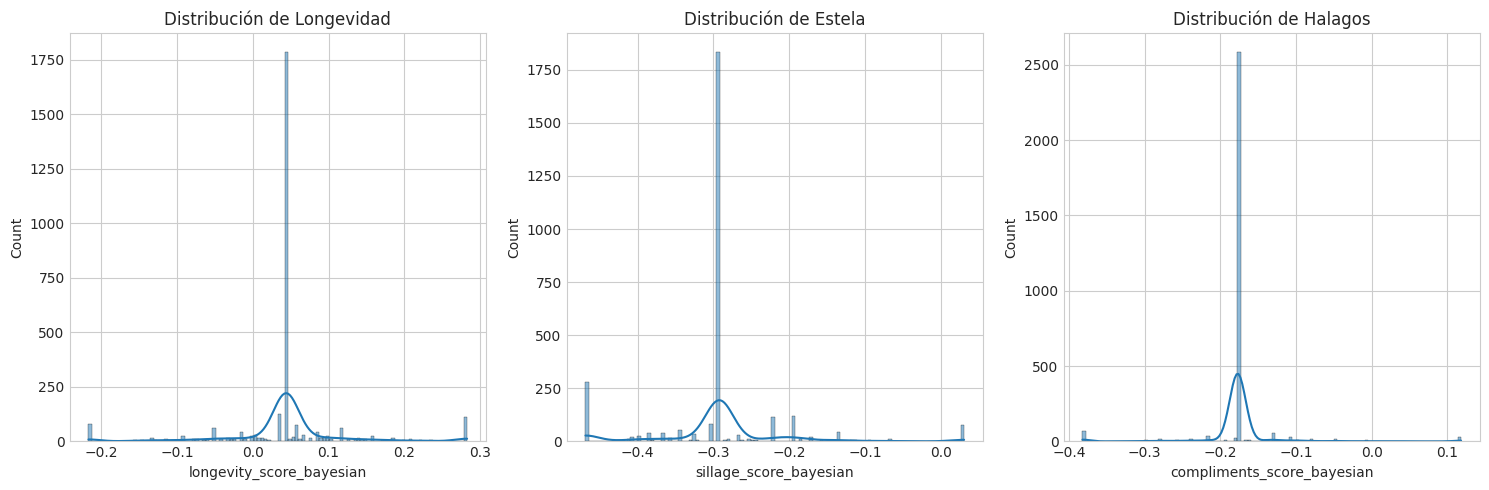

In [23]:
# Valores unicos de las metricas de perfume_performance_df
unique_longevity = perfume_performance_df['longevity_score_bayesian'].nunique()
unique_sillage = perfume_performance_df['sillage_score_bayesian'].nunique()
unique_compliment = perfume_performance_df['compliments_score_bayesian'].nunique()
print(f"\nNúmero de valores únicos para cada métrica:")
print(f"Longevidad: {unique_longevity}, Estela: {unique_sillage}, Halagos: {unique_compliment}")

print("Valores unicos de cada métrica:")
print(f"Longevidad: {perfume_performance_df['longevity_score_bayesian'].unique()}")
print(f"Estela: {perfume_performance_df['sillage_score_bayesian'].unique()}")
print(f"Halagos: {perfume_performance_df['compliments_score_bayesian'].unique()}")

#Distribución de métricas derivadas
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(perfume_performance_df['longevity_score_bayesian'], kde=True)
plt.title('Distribución de Longevidad')

plt.subplot(1, 3, 2)
sns.histplot(perfume_performance_df['sillage_score_bayesian'], kde=True)
plt.title('Distribución de Estela')

plt.subplot(1, 3, 3)
sns.histplot(perfume_performance_df['compliments_score_bayesian'], kde=True)
plt.title('Distribución de Halagos')

plt.tight_layout()
plt.show()


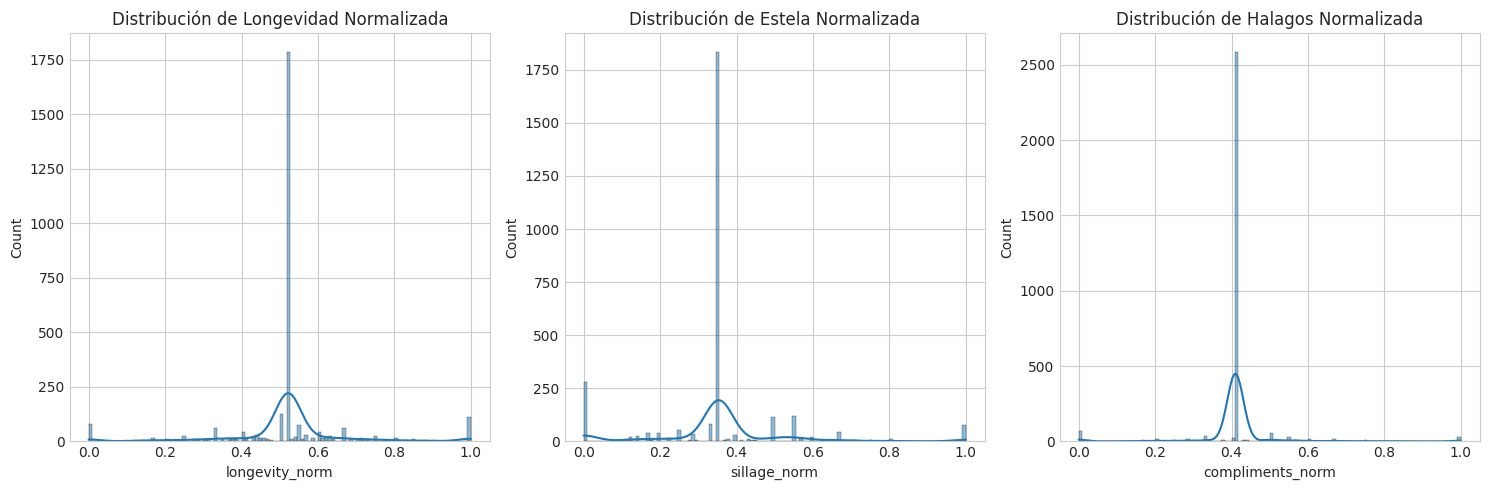

In [24]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
perfume_performance_df[['longevity_norm', 'sillage_norm', 'compliments_norm']] = scaler.fit_transform(
    perfume_performance_df[['longevity_score_bayesian', 'sillage_score_bayesian', 'compliments_score_bayesian']]
)

# Nuevas distribuciones normalizadas
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(perfume_performance_df['longevity_norm'], kde=True)
plt.title('Distribución de Longevidad Normalizada')

plt.subplot(1, 3, 2)
sns.histplot(perfume_performance_df['sillage_norm'], kde=True)
plt.title('Distribución de Estela Normalizada')

plt.subplot(1, 3, 3)
sns.histplot(perfume_performance_df['compliments_norm'], kde=True)
plt.title('Distribución de Halagos Normalizada')

plt.tight_layout()
plt.show()


podemos integrar las variables construidas (corpus TF-IDF ponderado, arquetipos, métricas bayesianas de reviews y distribución de sensaciones) para resolver dos tareas centrales:

Aprendizaje No Supervisado (Clustering / Profiling): Descubrir de forma automática los Perfiles Olfativos Subyacentes del mercado (agrupando perfumes según notas, estela, duración y arquetipos).

Sistema de Recomendación Híbrido (Content-Based + ML Vector Embeddings): Generar un espacio vectorial donde cada perfume y cada perfil de usuario tengan una posición matemática clara para recomendar por distancia/similitud.

''' text
[ Variables Generadas ]
     (TF-IDF Ponderado + Arquetipos + Metricas Reviews + Sintéticos)
                                 │
                                 ▼
                     [ Reducción de Dimensionalidad ]
                       (TruncatedSVD / PCA / UMAP)
                                 │
                                 ▼
                   [ Modelado No Supervisado (Clustering) ]
                   (K-Means / HDBSCAN / Gaussian Mixtures)
                                 │
                                 ▼
            ┌────────────────────┴────────────────────┐
            ▼                                         ▼
   [ Perfilamiento Olfativo ]               [ Motor de Recomendación ]
 - Segmentación automática de             - Mapeo de Usuario -> Perfil
   familias / arquetipos.                 - Cosine Similarity en Espacio
 - Caracterización por clúster.             Latente Reducido.


## INTEGRACION DE CARACTERISTICAS

In [26]:
import pandas as pd
import numpy as np
import ast
import re

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans

# ==============================================================================
# 1. PARSEO ROBUSO DE NOTAS USANDO LAS COLUMNAS _raw REALES
# ==============================================================================

def parse_any_notes_to_list(val) -> list:
    """Convierte cadenas/listas de notas en una lista limpia de strings."""
    if isinstance(val, list):
        return [str(x).strip() for x in val if x]
    if pd.isna(val) or not val or val == 'nan':
        return []
    if isinstance(val, str):
        val_str = val.strip()
        if val_str.startswith('[') and val_str.endswith(']'):
            try:
                parsed = ast.literal_eval(val_str)
                if isinstance(parsed, list):
                    return [str(x).strip() for x in parsed if x]
            except Exception:
                pass
        cleaned = re.sub(r"[\[\]'\"']", "", val_str)
        return [x.strip() for x in re.split(r'[,|/]', cleaned) if x.strip()]
    return []

def clean_note_text(note: str) -> str:
    note = str(note).lower().strip()
    note = re.sub(r'[^a-z0-9\s_]', '', note)
    return note.replace(' ', '_')

def create_weighted_corpus_from_raw(row):
    """Ponderación olfativa 3x Fondo, 2x Corazón, 1x Salida sobre columnas _raw."""
    top = [clean_note_text(n) for n in parse_any_notes_to_list(row.get('top_notes_raw'))]
    mid = [clean_note_text(n) for n in parse_any_notes_to_list(row.get('heart_notes_raw'))]
    base = [clean_note_text(n) for n in parse_any_notes_to_list(row.get('base_notes_raw'))]
    
    corpus = (top * 1) + (mid * 2) + (base * 3)
    return " ".join(corpus) if corpus else "unknown_note"

df_master = df_fixed.merge(perfume_performance_df, on='perfume_id', how='left')


# Re-generar el corpus con las columnas correctas
df_master['notes_corpus_weighted'] = df_master.apply(create_weighted_corpus_from_raw, axis=1)

print("--- REVISIÓN DE CORPUS GENERADO ---")
print(f"Total de registros con 'unknown_note': {(df_master['notes_corpus_weighted'] == 'unknown_note').sum()}")
print("Muestra del corpus:", df_master['notes_corpus_weighted'].head(2).tolist())


# ==============================================================================
# 2. VECTORIZACIÓN TF-IDF & TRUNCATED SVD
# ==============================================================================

tfidf = TfidfVectorizer(min_df=1, token_pattern=r'(?u)\b\w+\b')
tfidf_matrix = tfidf.fit_transform(df_master['notes_corpus_weighted'])

# Columnas numéricas para el espacio latente
num_cols = [
    'longevity_norm', 
    'sillage_norm', 
    'compliments_norm',
    'day_ratio', 
    'satisfaction_rate', 
    'controversy_index',
    'is_elegant', 
    'is_clean', 
    'is_leadership_boss', 
    'is_seductive', 
    'is_fresh_casual'
]

# Imputar nulos en numéricas si existieran
df_master[num_cols] = df_master[num_cols].fillna(0)

scaler = StandardScaler()
X_numeric_scaled = scaler.fit_transform(df_master[num_cols])

# Concatenar matrices
X_combined = hstack([tfidf_matrix, X_numeric_scaled]).tocsr()

n_samples, n_features = X_combined.shape
n_comp = min(15, min(n_samples, n_features) - 1)

svd = TruncatedSVD(n_components=n_comp, random_state=42)
X_embedding = svd.fit_transform(X_combined)



--- REVISIÓN DE CORPUS GENERADO ---
Total de registros con 'unknown_note': 0
Muestra del corpus: ['naranja_sanguina mandarina miel gardenia flor_de_azahar_del_naranjo jazmn durazno_melocotn miel gardenia flor_de_azahar_del_naranjo jazmn durazno_melocotn cera_de_abeja caramelo pachul regaliz cera_de_abeja caramelo pachul regaliz cera_de_abeja caramelo pachul regaliz', 'flor_de_azahar_del_naranjo mandarina durazno_melocotn peona jazmn azucena iris peona jazmn azucena iris almizcle notas_amaderadas mbar almizcle notas_amaderadas mbar almizcle notas_amaderadas mbar']


--- Tabla de Métricas por Número de Clusters ---
 k  Silhouette  Davies-Bouldin  Calinski-Harabasz      Inertia
 2    0.167551        2.165575         534.769394 28928.123030
 3    0.189758        1.943431         458.821645 26109.002843
 4    0.172914        2.124796         401.996733 24322.289585
 5    0.175923        1.949118         374.503712 22744.891896
 6    0.179237        1.798863         346.628286 21614.998407
 7    0.181859        1.787505         323.247889 20711.164179
 8    0.176181        1.978947         295.132669 20192.414831
 9    0.138734        1.796169         289.784913 19232.946527
10    0.158333        1.700198         282.936278 18440.001187


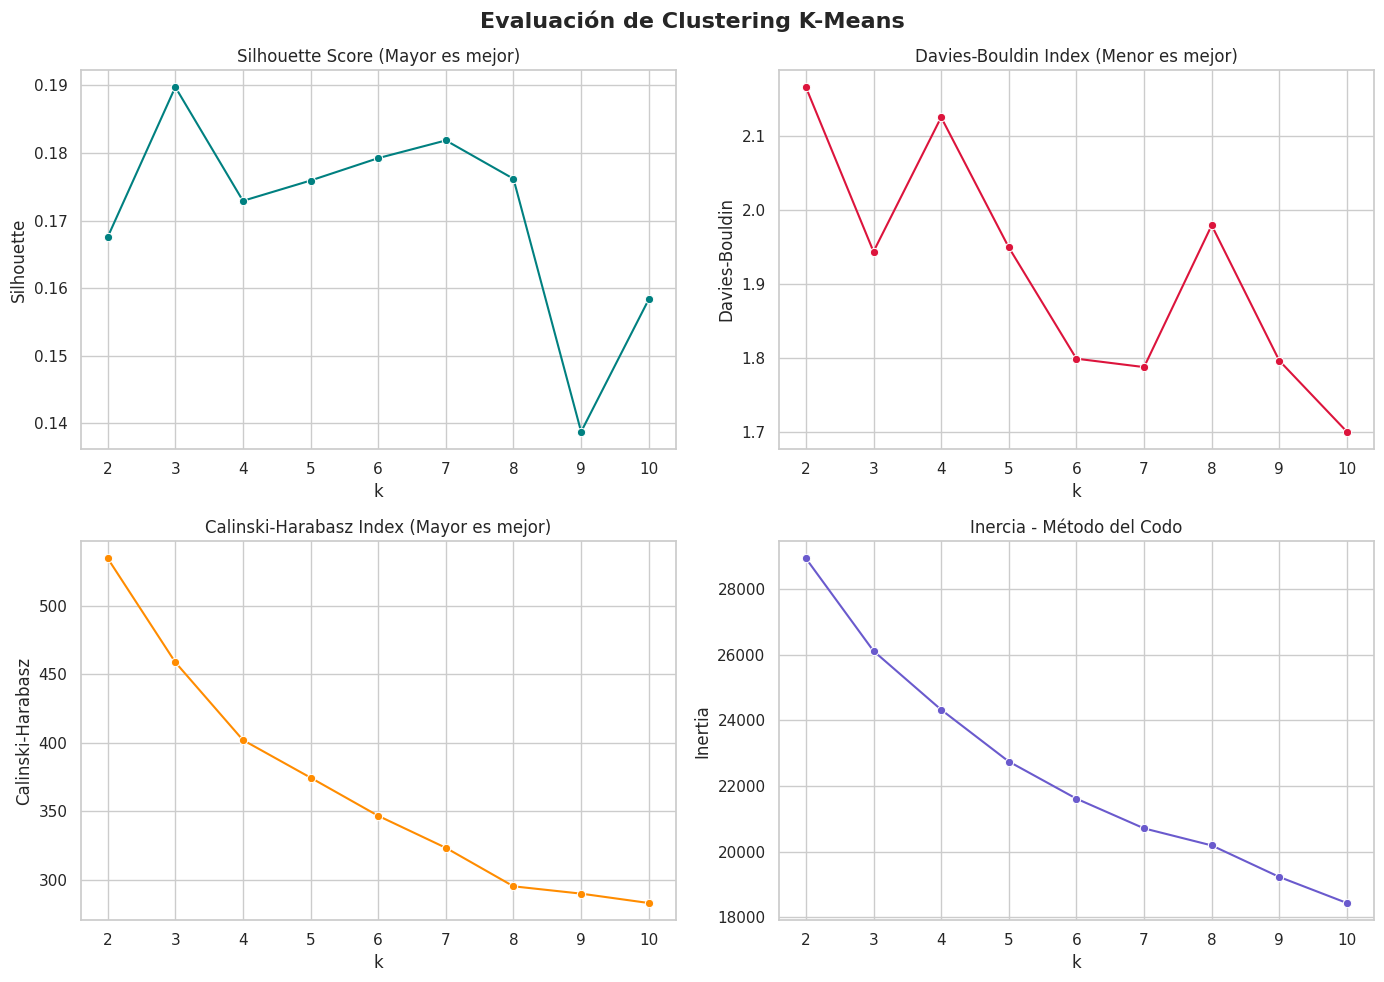

In [28]:

# ==============================================================================
# 3. ENTRENAMIENTO DE K-MEANS 
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# 1. Definir rango de clusters a evaluar
k_range = range(2, 11)

results = []

# 2. Bucle de entrenamiento y evaluación
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_embedding)
    
    # Cálculo de métricas
    sil = silhouette_score(X_embedding, cluster_labels)
    db = davies_bouldin_score(X_embedding, cluster_labels)
    ch = calinski_harabasz_score(X_embedding, cluster_labels)
    inertia = kmeans.inertia_  # Método del codo (opcional pero útil)
    
    results.append({
        'k': k,
        'Silhouette': sil,
        'Davies-Bouldin': db,
        'Calinski-Harabasz': ch,
        'Inertia': inertia
    })

# 3. Consolidar resultados en un DataFrame
df_metrics = pd.DataFrame(results)

print("--- Tabla de Métricas por Número de Clusters ---")
print(df_metrics.to_string(index=False))


# 4. Generación de Gráficas
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Evaluación de Clustering K-Means', fontsize=16, fontweight='bold')

sns.set_theme(style="whitegrid")

# Silhouette Score (Máximo es mejor)
sns.lineplot(ax=axes[0, 0], data=df_metrics, x='k', y='Silhouette', marker='o', color='teal')
axes[0, 0].set_title('Silhouette Score (Mayor es mejor)')
axes[0, 0].set_xticks(list(k_range))

# Davies-Bouldin Index (Mínimo es mejor)
sns.lineplot(ax=axes[0, 1], data=df_metrics, x='k', y='Davies-Bouldin', marker='o', color='crimson')
axes[0, 1].set_title('Davies-Bouldin Index (Menor es mejor)')
axes[0, 1].set_xticks(list(k_range))

# Calinski-Harabasz Index (Máximo es mejor)
sns.lineplot(ax=axes[1, 0], data=df_metrics, x='k', y='Calinski-Harabasz', marker='o', color='darkorange')
axes[1, 0].set_title('Calinski-Harabasz Index (Mayor es mejor)')
axes[1, 0].set_xticks(list(k_range))

# Inertia / Método del Codo
sns.lineplot(ax=axes[1, 1], data=df_metrics, x='k', y='Inertia', marker='o', color='slateblue')
axes[1, 1].set_title('Inercia - Método del Codo')
axes[1, 1].set_xticks(list(k_range))

plt.tight_layout()
plt.show()



Criterios para Elegir el $k$ Óptimo

Silhouette Score: Busca el valor más alto (picos en la curva). Mide qué tan similar es un punto a su propio cluster en comparación con otros.

Davies-Bouldin Index: Busca el valor más bajo (valles en la curva). Mide la separación relativa entre clusters respecto a su dispersión interna.

Calinski-Harabasz Index: Busca un valor alto o un punto de inflexión. Representa la razón entre la dispersión entre clusters y la dispersión intra-cluster.

Inercia (Elbow): Busca el "codo" donde la tasa de reducción de la varianza interna disminuye de forma considerable.

In [29]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

k_range = range(2, 11)
results = []

for k in k_range:
    # 1. K-Means
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_km = km.fit_predict(X_embedding)
    
    # 2. Agglomerative (con enlace Ward y distancia euclídea)
    agg = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels_agg = agg.fit_predict(X_embedding)
    
    # 3. Gaussian Mixture Model
    gmm = GaussianMixture(n_components=k, random_state=42)
    labels_gmm = gmm.fit_predict(X_embedding)
    
    # Registro de métricas por modelo
    models_eval = [
        ('K-Means', labels_km),
        ('Agglomerative', labels_agg),
        ('GMM', labels_gmm)
    ]
    
    for model_name, labels in models_eval:
        sil = silhouette_score(X_embedding, labels)
        db = davies_bouldin_score(X_embedding, labels)
        ch = calinski_harabasz_score(X_embedding, labels)
        
        results.append({
            'Model': model_name,
            'k': k,
            'Silhouette': sil,
            'Davies-Bouldin': db,
            'Calinski-Harabasz': ch
        })

# Consolidar en DataFrame
df_comparison = pd.DataFrame(results)

# Mostrar los 5 mejores resultados según Silhouette Score
print("--- Top 5 Configuraciones por Silhouette Score ---")
print(df_comparison.sort_values(by='Silhouette', ascending=False).head(5).to_string(index=False))

--- Top 5 Configuraciones por Silhouette Score ---
        Model  k  Silhouette  Davies-Bouldin  Calinski-Harabasz
Agglomerative  2    0.236586        1.667719         300.278632
      K-Means  3    0.189758        1.943431         458.821645
      K-Means  7    0.181859        1.787505         323.247889
      K-Means  6    0.179237        1.798863         346.628286
      K-Means  8    0.176181        1.978947         295.132669


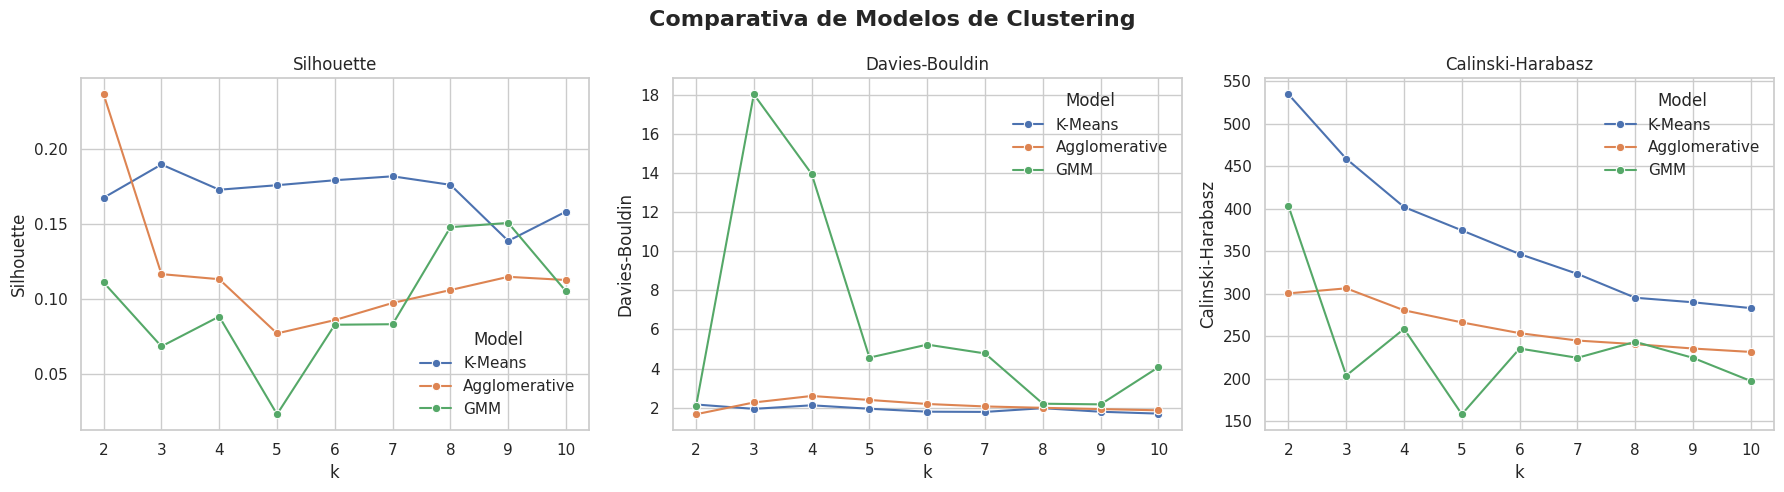

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Comparativa de Modelos de Clustering', fontsize=16, fontweight='bold')

metrics = ['Silhouette', 'Davies-Bouldin', 'Calinski-Harabasz']

for i, metric in enumerate(metrics):
    sns.lineplot(
        ax=axes[i],
        data=df_comparison,
        x='k',
        y=metric,
        hue='Model',
        marker='o'
    )
    axes[i].set_title(f'{metric}')
    axes[i].set_xticks(list(k_range))
    axes[i].grid(True)

plt.tight_layout()
plt.show()

ELegimos K-Means ya que muestra un mejor comportamiento mientras k aumenta, no existe tanta volatilidad en las métricas utilizadas.

Por otro lado, el numero de clusters optimos parace estar entre 3 y 4, sin embargo, por decision de negocio podemos usar 6 ya que con el periflamiento podemos armar al menos este numero de grupos bien diferenciados de acuerdo a las notas que predominen en los perfumes,

In [31]:

k_optimal = 6  # Ajusta este valor según tus gráficas

kmeans_model = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
df_master['olfactory_cluster'] = kmeans_model.fit_predict(X_embedding)
df_master['distance_to_cluster_center'] = kmeans_model.transform(X_embedding).min(axis=1)

In [32]:
df_master.head(10)

,url,bottle_image_url,name_raw,designer_raw,global_rating,global_rating_count,top_notes_raw,heart_notes_raw,base_notes_raw,vibe_reactions_raw_dist,...,best_season,day_ratio,longevity_score_bayesian,sillage_score_bayesian,compliments_score_bayesian,longevity_norm,sillage_norm,compliments_norm,olfactory_cluster,distance_to_cluster_center
0,https://www.fragrantica.es/perfume/Jean-Paul-G...,https://fimgs.net/mdimg/perfume-thumbs/375x500...,Scandal Jean Paul Gaultier para Mujeres,Jean Paul Gaultier,3.86,"9,804","naranja sanguina, mandarina","miel, gardenia, flor de azahar del naranjo, ja...","cera de abeja, caramelo, pachulí, regaliz","{""me encanta"": ""3.9k"", ""me gusta"": ""3k"", ""me e...",...,invierno,0.368421,0.033,0.031,-0.215,0.500,1.000,0.334,0,4.142799
1,https://www.fragrantica.es/perfume/Elizabeth-A...,https://fimgs.net/mdimg/perfume-thumbs/375x500...,Pretty Elizabeth Arden para Mujeres,Elizabeth Arden,3.77,"1,153","flor de azahar del naranjo, mandarina, durazno...","peonía, jazmín, azucena, iris","almizcle, notas amaderadas, ámbar","{""me encanta"": ""260"", ""me gusta"": ""594"", ""me e...",...,verano,0.888689,-0.002,-0.344,-0.177,0.430,0.250,0.410,2,2.259713
2,https://www.fragrantica.es/perfume/Dior/Dior-A...,https://fimgs.net/mdimg/perfume-thumbs/375x500...,Dior Addict Shine Dior para Mujeres,Dior,4.07,"1,120",Sin notas declaradas,Sin notas declaradas,Sin notas declaradas,"{""me encanta"": ""379"", ""me gusta"": ""584"", ""me e...",...,verano,0.860687,0.058,-0.344,-0.382,0.550,0.250,0.000,0,4.128023
3,https://www.fragrantica.es/perfume/Granado/San...,https://fimgs.net/mdimg/perfume-thumbs/375x500...,Sândalo e Cardamomo Granado para Hombres y Muj...,Granado,3.54,145,"cardamomo, semillas de zanahoria, hojas de vio...","cachemira, vetiver, vainilla","sándalo, almizcle, cedro","{""me encanta"": ""45"", ""me gusta"": ""41"", ""me es ...",...,otoño,0.513514,0.044,-0.292,-0.177,0.522,0.354,0.410,5,2.430608
4,https://www.fragrantica.es/perfume/Yves-Saint-...,https://fimgs.net/mdimg/perfume-thumbs/375x500...,Kouros Cologne Sport Eau d'Ete Summer Fragranc...,Yves Saint Laurent,4.14,42,"menta, bergamota","lavanda, jazmín","ámbar blanco, cedro","{""me encanta"": ""19"", ""me gusta"": ""17"", ""me es ...",...,verano,0.611111,0.044,-0.292,-0.177,0.522,0.354,0.410,1,2.020478
5,https://www.fragrantica.es/perfume/Fragrance-W...,https://fimgs.net/mdimg/perfume-thumbs/375x500...,Little Black Dress Fragrance World para Mujeres,Fragrance World,4.00,6,"té negro, bayas rojas, bergamota",rosa negra,"haba tonka, almendra","{""me encanta"": ""3"", ""me gusta"": ""2"", ""me es in...",...,otoño,0.500000,0.044,-0.292,-0.177,0.522,0.354,0.410,2,1.634408
6,https://www.fragrantica.es/perfume/Bath-Body-W...,https://fimgs.net/mdimg/perfume-thumbs/375x500...,Fresh Vanilla Blossoms Bath & Body Works para ...,Bath & Body Works,4.30,236,Sin notas declaradas,Sin notas declaradas,Sin notas declaradas,"{""me encanta"": ""122"", ""me gusta"": ""81"", ""me es...",...,otoño,0.715232,0.033,-0.194,-0.177,0.500,0.550,0.410,0,1.444558
7,https://www.fragrantica.es/perfume/Natura/Humo...,https://fimgs.net/mdimg/perfume-thumbs/375x500...,Humor no Ar Natura para Mujeres,Natura,4.12,137,"manzana, ciruela, níspero japonés, nuez moscad...","coñac, lirio de los valles (muguete), fresia, ...","vainilla, ámbar, haba tonka, sándalo, benjuí, ...","{""me encanta"": ""53"", ""me gusta"": ""64"", ""me es ...",...,otoño,0.781609,0.140,-0.219,-0.132,0.714,0.500,0.500,1,2.669169
8,https://www.fragrantica.es/perfume/Arabiyat-Pr...,https://fimgs.net/mdimg/perfume-thumbs/375x500...,Portrait Café Noir Arabiyat Prestige para Homb...,Arabiyat Prestige,5.00,7,"bergamota, grosellas negras","Akigalawood, pachulí, caramelo","Evernil, ámbar, almizcle","{""me encanta"": ""7"", ""me gusta"": ""0"", ""me es in...",...,verano,0.600000,0.044,-0.292,-0.177,0.522,0.354,0.410,2,2.648889
9,https://www.fragrantica.es/perfume/Comme-des-G...,https://fimgs.net/mdimg/perfume-thumbs/375x500...,Ganja Comme 

In [33]:

# ==============================================================================
# 4. GENERACIÓN DEL PERFILAMIENTO FINAL DE CLÚSTERES
# ==============================================================================

def generate_cluster_profiles(df, tfidf_vectorizer, tfidf_mat, num_columns, cluster_col='olfactory_cluster'):
    feature_names = np.array(tfidf_vectorizer.get_feature_names_out())
    clusters = sorted(df[cluster_col].unique())
    global_means = df[num_columns].mean()
    
    profiles = []

    for c in clusters:
        cluster_mask = (df[cluster_col] == c)
        cluster_df = df[cluster_mask]
        cluster_size = len(cluster_df)
        
        # 1. Variables numéricas destacadas
        cluster_means = cluster_df[num_columns].mean()
        diff = cluster_means - global_means
        
        top_positive_traits = diff.sort_values(ascending=False).head(3).to_dict()
        top_negative_traits = diff.sort_values(ascending=True).head(2).to_dict()

        # 2. Top 5 notas TF-IDF reales del clúster
        cluster_tfidf = tfidf_mat[cluster_mask.values].mean(axis=0)
        top_note_indices = np.argsort(np.asarray(cluster_tfidf).flatten())[::-1][:5]
        top_notes = feature_names[top_note_indices].tolist()

        profiles.append({
            'cluster_id': c,
            'size': cluster_size,
            'pct_of_total': f"{(cluster_size / len(df)) * 100:.1f}%",
            'top_notes': ", ".join(top_notes),
            'high_traits': [f"{k} (+{v:.2f})" for k, v in top_positive_traits.items() if v > 0.02],
            'low_traits': [f"{k} ({v:.2f})" for k, v in top_negative_traits.items() if v < -0.02]
        })

    return pd.DataFrame(profiles)

df_profiles = generate_cluster_profiles(df_master, tfidf, tfidf_matrix, num_cols)

# Mostrar la tabla de perfiles limpia
pd.set_option('display.max_colwidth', None)
print("\n--- PERFILAMIENTO FINAL DE LOS 9 CLÚSTERES OLFATIVOS ---")
print(df_profiles[['cluster_id', 'size', 'pct_of_total', 'top_notes', 'high_traits','low_traits']])


--- PERFILAMIENTO FINAL DE LOS 9 CLÚSTERES OLFATIVOS ---
   cluster_id  size pct_of_total  \
0           0  1076        35.7%   
1           1   264         8.8%   
2           2   707        23.4%   
3           3   186         6.2%   
4           4    71         2.4%   
5           5   712        23.6%   

                                                top_notes  \
0    sin_notas_declaradas, vainilla, sndalo, mbar, pachul   
1                 almizcle, mbar, cedro, sndalo, vainilla   
2                almizcle, vainilla, mbar, sndalo, pachul   
3    sin_notas_declaradas, almizcle, mbar, sndalo, pachul   
4  sin_notas_declaradas, vainilla, mbar, almizcle, pachul   
5                    cedro, almizcle, mbar, pachul, cuero   

                                                               high_traits  \
0                                                                       []   
1  [is_fresh_casual (+0.91), is_clean (+0.27), is_leadership_boss (+0.21)]   
2             [is_clean (+0

Cluster 0: Oriental/Cálido Pesado (Gourmand Denso)
Perfil de notas: Vainilla, sándalo, ámbar, pachulí (con sin_notas_declaradas al inicio).

Rasgos destacados: No presenta ningún rasgo positivo sobresaliente en high_traits.

Rasgos bajos: Muy bajo en frescura y elegancia (is_clean: -0.50, is_elegant: -0.34).

Interpretación: Un perfil fuertemente orientado a lo dulzón, resinoso y denso. Al carecer de salidas frescas o limpias, pierde la versatilidad informal y la elegancia refinada, quedando como un aroma pesado o nocturno muy específico.

Cluster 1: Amaderado Fresco e Informal (Liderazgo Casual)
Perfil de notas: Almizcle, ámbar, cedro, sándalo, vainilla.

Rasgos destacados: Marcadamente fresco e informal (is_fresh_casual: +0.91), limpio (is_clean: +0.27) y con matices de autoridad (is_leadership_boss: +0.21).

Rasgos bajos: Ningún penalizador relevante en low_traits.

Interpretación: El signature scent de uso diario/oficina. Combina la pulcritud del almizcle y la frescura con una base amaderada sólida (cedro/sándalo) que transmite profesionalismo y liderazgo sin resultar pretencioso ni pesado.

Cluster 2: Sensual Limpio y Atalcado (Elegancia Íntima)
Perfil de notas: Almizcle, vainilla, ámbar, sándalo, pachulí.

Rasgos destacados: Sensación de pulcritud (is_clean: +0.42), seductor (is_seductive: +0.21) y elegante (is_elegant: +0.18).

Rasgos bajos: Carece de vibra imponente u opulenta (is_leadership_boss: -0.31) y de frescura desenfadada (is_fresh_casual: -0.09).

Interpretación: Fragancias sutiles, elegantes y de proximidad. Es un perfil de "piel limpia" con una base cálida/atrayente (almizcle + vainilla), ideal para citas o eventos formales donde se busca seducir de forma discreta y no imponer autoridad.

Cluster 3: Polémico y Divisivo (Nicho / Retador)
Perfil de notas: Almizcle, ámbar, sándalo, pachulí (con sin_notas_declaradas al inicio).

Rasgos destacados: Alto índice de controversia (controversy_index: +0.24), uso diurno moderado (day_ratio: +0.06) y proyección estándar (sillage_norm: +0.02).

Rasgos bajos: Menor tasa de satisfacción general (satisfaction_rate: -0.27) y bajo en seducción (is_seductive: -0.16).

Interpretación: Fragancias retadoras o tipo polarizing/love-it-or-hate-it. Su composición genera opiniones divididas en la comunidad, lo que reduce su nivel de satisfacción general y lo aleja del perfil tradicionalmente seductor o masivo.

Cluster 4: El Imán de Cumplidos (Dulce Nocturno / Versátil Elegante)
Perfil de notas: Vainilla, ámbar, almizcle, pachulí (con sin_notas_declaradas al inicio).

Rasgos destacados: Altísima tasa de cumplidos (compliments_norm: +0.44), elegante (is_elegant: +0.12) y seductor (is_seductive: +0.12).

Rasgos bajos: Ligeramente acotado para uso diurno (day_ratio: -0.06) y baja frescura casual (is_fresh_casual: -0.04).

Interpretación: Fragancias orientales-dulces diseñadas para gustar a las masas (crowd-pleasers). La combinación de vainilla y ámbar sobre pachulí resulta sumamente atractiva para el entorno, haciéndola destacar principalmente en salidas nocturnas o eventos.

Cluster 5: Cuero Amaderado de Autoridad (Alfa / Formal Oscuro)
Perfil de notas: Cedro, almizcle, ámbar, pachulí, cuero.

Rasgos destacados: Máxima presencia de liderazgo y autoridad (is_leadership_boss: +0.69), altamente elegante (is_elegant: +0.32) y pulcro (is_clean: +0.25).

Rasgos bajos: Nada versátil para el día a día informal (is_fresh_casual: -0.09, day_ratio: -0.07).

Interpretación: El perfil corporativo o formal por excelencia. La incorporación distintiva de la nota de cuero junto al cedro le da una estructura imponente, madura y de alto estatus, reservada para traje/sastrería o situaciones directivas.

In [34]:
# Diccionario de asignación de nombres de perfil
olfactory_profile_map = {
    0: "Oriental / gourmand",
    1: "Amaderado fresco e Informal",
    2: "Limpio y atalcado",
    3: "Nicho / Retador",
    4: "Dulce Nocturno / Versátil Elegante",
    5: "Cuero Amaderado de Autoridad"
}

# Asignar la columna explicativa en df_master
df_master['olfactory_profile_label'] = df_master['olfactory_cluster'].map(olfactory_profile_map)

# Verificar distribución final por nombre de perfil
print(df_master['olfactory_profile_label'].value_counts())

olfactory_profile_label
Oriental / gourmand                   1076
Cuero Amaderado de Autoridad           712
Limpio y atalcado                      707
Amaderado fresco e Informal            264
Nicho / Retador                        186
Dulce Nocturno / Versátil Elegante      71
Name: count, dtype: int64


In [41]:
import plotly.express as px

def generar_radar_plotly(df, col_listas, titulo, top_n=8):
    df_exp = df.explode(col_listas)
    
    # Filtro para eliminar la nota no deseada
    notas_a_excluir = ['sin notas declaradas', 'sin nota declarada', 'sin notas', 'none', 'nan']
    df_exp = df_exp[~df_exp[col_listas].astype(str).str.strip().str.lower().isin(notas_a_excluir)]
    
    dummies = pd.get_dummies(df_exp[col_listas], prefix='', prefix_sep='')
    perfumes_notes = dummies.groupby([df_exp.index, df_exp['olfactory_profile_label']]).max()
    cluster_pct = perfumes_notes.groupby('olfactory_profile_label').mean()
    
    if cluster_pct.shape[1] > top_n:
        top_cols = cluster_pct.sum().nlargest(top_n).index
        cluster_pct = cluster_pct[top_cols]
        
    df_long = pd.melt(
        cluster_pct.reset_index(), 
        id_vars=['olfactory_profile_label'], 
        var_name='Nota', 
        value_name='Presencia'
    )
    
    fig = px.line_polar(
        df_long, 
        r='Presencia', 
        theta='Nota', 
        color='olfactory_profile_label', 
        line_close=True,
        title=titulo
    )
    fig.update_traces(fill='toself', opacity=0.8)
    fig.show()

# Llamadas
generar_radar_plotly(df_master, 'top_notes_raw', 'Notas de Salida (Top Notes)')
generar_radar_plotly(df_master, 'heart_notes_raw', 'Notas de Corazón (Heart Notes)')
generar_radar_plotly(df_master, 'base_notes_raw', 'Notas de Fondo (Base Notes)')

Recomendación Basada en Perfil Olfativo del Usuario
Imagina que un nuevo usuario completa un test o expresa su preferencia (ej. "busco algo limpio, elegante y de buena duración"). Podemos vectorizar el perfil del usuario, proyectarlo en el mismo espacio vectorial de Machine Learning y calcular los perfumes más cercanos dentro de su mismo clúster olfativo.

In [35]:
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix, hstack
from sklearn.metrics.pairwise import cosine_similarity

# Diccionario de asignación de nombres de perfil
olfactory_profile_map = {
    0: "Oriental / gourmand",
    1: "Amaderado fresco e Informal",
    2: "Limpio y atalcado",
    3: "Nicho / Retador",
    4: "Dulce Nocturno / Versátil Elegante",
    5: "Cuero Amaderado de Autoridad"
}


def recommend_by_user_preference(
    user_preferences: dict, 
    df: pd.DataFrame, 
    X_embed, 
    tfidf_mat,
    model_kmeans, 
    scaler_obj, 
    svd_obj, 
    top_n: int = 5
):
    """
    Recomienda perfumes proyectando las preferencias del usuario al espacio vectorial del modelo.
    """
    # 1. Construir el vector numérico del usuario respetando el orden exacto de num_cols
    user_num_vector = np.array([[
        user_preferences.get('longevity_norm', 0.5),
        user_preferences.get('sillage_norm', 0.5),
        user_preferences.get('compliments_norm', 0.5),
        user_preferences.get('day_ratio', 0.5),
        user_preferences.get('satisfaction_rate', 0.8),
        user_preferences.get('controversy_index', 0.1),
        user_preferences.get('is_elegant', 0),
        user_preferences.get('is_clean', 0),
        user_preferences.get('is_leadership_boss', 0),
        user_preferences.get('is_seductive', 0),
        user_preferences.get('is_fresh_casual', 0)
    ]])

    # Escalado con el StandardScaler entrenado
    user_num_scaled = scaler_obj.transform(user_num_vector)
    
    # Matriz sparse de ceros con la forma EXACTA de 1 fila x N columnas de TF-IDF
    n_tfidf_features = tfidf_mat.shape[1]
    user_tfidf_dummy = csr_matrix((1, n_tfidf_features), dtype=np.float64)
    
    # Concatenar vector de texto (ceros) con vector numérico escalado
    user_combined = hstack([user_tfidf_dummy, user_num_scaled]).tocsr()
    
    # Proyección al espacio reducido TruncatedSVD
    user_embedding = svd_obj.transform(user_combined)

    # 2. Predecir el clúster olfativo
    predicted_cluster = model_kmeans.predict(user_embedding)[0]
    predicted_profile = olfactory_profile_map.get(predicted_cluster, f"Clúster {predicted_cluster}")

    # 3. Filtrar perfumes que pertenecen al mismo perfil
    cluster_mask = (df['olfactory_cluster'] == predicted_cluster)
    cluster_indices = np.where(cluster_mask)[0]
    
    if len(cluster_indices) == 0:
        cluster_indices = np.arange(len(df))

    # 4. Similitud del coseno en el espacio latente
    sims = cosine_similarity(user_embedding, X_embed[cluster_indices]).flatten()
    
    # 5. Formatear y ordenar los resultados
    results = df.iloc[cluster_indices].copy()
    results['similarity'] = sims
    
    recommended = results.sort_values(by='similarity', ascending=False).head(top_n)

    # Seleccionar columnas disponibles para mostrar
    cols_to_show = ['name_raw', 'designer_raw', 'olfactory_profile_label', 'similarity', 'best_season', 'satisfaction_rate']
    present_cols = [c for c in cols_to_show if c in recommended.columns]

    return predicted_profile, recommended[present_cols]


# ==========================================
# EJEMPLO DE EJECUCIÓN
# ==========================================

user_test = {
    'is_clean': 1,
    'is_fresh_casual': 1,
    'day_ratio': 0.85,
    'longevity_norm': 0.6,
    'sillage_norm': 0.4
}

profile, recs = recommend_by_user_preference(
    user_preferences=user_test,
    df=df_master,
    X_embed=X_embedding,
    tfidf_mat=tfidf_matrix,
    model_kmeans=kmeans_model,
    scaler_obj=scaler,
    svd_obj=svd,
    top_n=5
)

print(f"\n--- PERFIL OLFATIVO PREDICHO PARA EL USUARIO: {profile} ---\n")
print(recs.to_string(index=False))


--- PERFIL OLFATIVO PREDICHO PARA EL USUARIO: Amaderado fresco e Informal ---

                                                   name_raw designer_raw     olfactory_profile_label  similarity best_season  satisfaction_rate
Cuide-se Bem Bob Esponja O Boticário para Hombres y Mujeres  O Boticário Amaderado fresco e Informal    0.961311      verano           0.775000
                    Odyssey Aqua Edition Armaf para Hombres        Armaf Amaderado fresco e Informal    0.960802      verano           0.852130
          XS Pour Homme Sensual Summer Rabanne para Hombres      Rabanne Amaderado fresco e Informal    0.956223      verano           0.840909
        Cuide-se Bem Bendito Cacto O Boticário para Mujeres  O Boticário Amaderado fresco e Informal    0.939478      verano           0.784062
                      Elle Anniversary Xerjoff para Mujeres      Xerjoff Amaderado fresco e Informal    0.935793      verano           0.710145
